# TSARA, Phase 5 — the continuous baseline state

**A walkthrough you can run, change and try to break.** Every number and figure
below is produced by the package from data manufactured inside this notebook,
where the true background under every plume is known. No real measurement is
read, and nothing needs mounting. Notebook `05b` runs the same operations on the
campaign archive.

---

## How to use this notebook

1. **Run everything once** (*Run All*, under two minutes).
2. **Every section stands on its own.** Each opens with a **parameters cell**: a
   short list of CAPITALISED names, each commented with what it controls. Change
   a value, then run that section's cells from the parameters cell down to the
   next heading. A section reads nothing another section made; all of them
   share only the two setup cells below.
3. **Every section prints checks.** A line beginning ✔ is a claim about TSARA,
   compared *as it ran* against a calculation written independently in this
   notebook: a loop written from the definition, a closed form, the
   generator's answer key, or random draws whose truth is known. The checks are
   written to hold at *any* parameters you choose. If you ever see ✘, you have
   found an edge case worth understanding or a bug. Either way, bring it back.
4. **"Try it"** notes after each section suggest a change and say what should
   happen. Each prediction was run before this notebook was committed.
5. **Section 9** collects every check into one scoreboard, and lists what is
   known to be imperfect.

When a section describes package code, it names the function and the file, for
example `rolling_quantile` in `src/tsara/baseline/quantile.py`. That code is
commented so that it can be read alongside.

---

## What this phase delivers

You decided on 2026-09-24 that the continuous baseline state is **per stream, at
native rate, beside the readings**: for every reading of every instrument and
every point of a window × quantile sweep, the baseline and the enhancement,
with their uncertainties. Not a grid product. Phase 5 built that, and this
notebook shows each part doing its job with the truth beside it:

| | Property | Tested in |
|---|---|---|
| 1 | **One weighted quantile**, defined once: each reading counts by the share of its cell inside the window | §1, §2 |
| 2 | **A baseline is stated with its window**: what is baseline at one window is signal at another | §2 |
| 3 | **Blank with the reason recorded, never an error**: a window too thin for a quantile, or a reading too wide for a window | §3, §4 |
| 4 | **Options for a sparse instrument**: another instrument's baseline of the same field, or a declared constant | §5, §6 |
| 5 | **Honest uncertainty on the baseline and the enhancement**: never clipped, and `unknown` said out loud where the reading declares none | §2, §7 |
| 6 | **The state saves, reloads exactly, and joins like a stream** | §8 |

What this phase does **not** do: plume detection (Phase 6), regression and the
stability cube (Phase 7). The noise scale detection quotes its thresholds in
was built here and moved to Phase 6 on 2026-09-29, beside the detect and
re-estimate loop it belongs to (`METHODS.md` §2.5).

---

## Vocabulary used throughout

| term | meaning |
|---|---|
| **cell** | the interval of air one row describes. Stored as `time_bnds` (start, stop); `time` is its midpoint |
| **window** | a duration centred on a reading's cell, over which a rolling statistic is taken. A window is itself a cell |
| **baseline at window *w*** | the low quantile of a variable over the window of length *w* around a reading; always stated with its window |
| **enhancement** | reading minus baseline, at that window and quantile; negative in clean air, never clipped |
| **sweep point** | one (window, quantile) pair of the configured sweep; the state has one baseline per reading per sweep point |
| **overlap weight** | how much of a reading's cell (in nanoseconds) falls inside a window |
| **count rule** | a window holding fewer readings than `min_readings` (default ⌈1/q⌉) for a quantile is blank at that quantile |
| **width rule** | a window holding a reading at least twice as wide as itself is blank: a wide reading is not stood on a narrow window |
| **blank** | a sweep point with no baseline at a reading, with the reason recorded beside it |
| **provenance** | where a number came from: `declared`, `reported`, `inferred`, `assumed`, `empirical`; for an uncertainty also `zero` (a budget that omits it) or `unknown` (none stated) |
| **field** | a physical quantity of the atmosphere, e.g. `benzene`; two instruments measuring one field share one background |
| **source** | an *emission* source only: a landfill, a gas line, a refinery. Never the input of a join or where a number came from |

---
## Setup (run these two cells first)

The first cell is the **toolkit**: imports, the figure style shared by
notebooks 01–05, helpers for building and drawing streams, and the
**reference implementations** every check compares TSARA against. The second
holds the **campaign recipes**, one function per synthetic campaign, whose
keyword arguments are the knobs the sections expose.

In [1]:
# =============================================================================
# TOOLKIT. Every section needs this cell and nothing else from other sections.
# =============================================================================
import logging
import tempfile
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy.stats import norm

from tsara import setup_logging
from tsara.align import bin_streams_onto_cells
from tsara.baseline import (
    TsaraBaselineError,
    baseline_state,
    load_state,
    rolling_quantile,
    save_state,
    weighted_quantile,
    window_cells,
)
from tsara.config.analysis import BaselineConfig
from tsara.config.synthetic import SyntheticConfig
from tsara.core.support import CellBounds, stream_cells
from tsara.synthetic import generate

SECOND = 1_000_000_000  # TSARA keeps every time as integer nanoseconds

# --- 1. figure style (identical to notebooks 01-04) --------------------------
C1, C2, C3 = "#0072b2", "#e69f00", "#009e73"  # Okabe-Ito blue, amber, green: colour-blind safe
C4 = "#cc79a7"  # Okabe-Ito purple, for a fourth series
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.size": 9.5,
        "lines.linewidth": 1.4,
        "figure.dpi": 110,
    }
)


def finish(
    ax, title=None, sub=None, ylab=None, xlab=None, legend=False, grid_axis="y", loc="upper right"
):
    """Apply the shared chrome: left-aligned title, muted subtitle, hairline grid."""
    if title:
        ax.set_title(title, pad=19 if sub else 8)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=8.8, color=MUTED, va="bottom")
    if ylab:
        ax.set_ylabel(ylab)
    if xlab:
        ax.set_xlabel(xlab)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    if legend:
        ax.legend(loc=loc)


def hhmm(ax, fmt="%H:%M"):
    """Label the x axis as clock time; the date belongs in the title."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def break_gaps(clock, values, tolerance=5.0):
    """Insert a NaN wherever the clock jumps, so matplotlib draws no line across a gap.

    A plotted line is a straight segment between neighbouring points, so a hole
    in a record would otherwise render as a smooth ramp across it: exactly the
    interpolation TSARA refuses to perform on a gas.
    """
    clock, values = np.asarray(clock), np.asarray(values, dtype=float)
    steps = np.diff(clock).astype("timedelta64[ms]").astype(float)
    gaps = np.where(steps > tolerance * np.median(steps))[0]
    if gaps.size == 0:
        return clock, values
    return np.insert(clock, gaps + 1, clock[gaps]), np.insert(values, gaps + 1, np.nan)


def overview_strip(ax, clock, values, window, label):
    """Draw the whole record thinly and shade the zoomed window: where the figure below sits."""
    clock, values = break_gaps(clock, values)
    ax.plot(clock, values, color=MUTED, lw=0.5)
    ax.axvspan(window[0], window[1], color=C2, alpha=0.25, lw=0)
    ax.set_yticks([])
    ax.set_ylabel(label, fontsize=8, color=MUTED)
    ax.tick_params(axis="x", labelsize=7.5)
    hhmm(ax)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)


# --- 2. streams and cells -----------------------------------------------------
def cells_of(stream):
    """Return a stream's cells as CellBounds: integer-nanosecond starts and stops."""
    edges = stream["time_bnds"].values.astype("datetime64[ns]").astype("int64")
    return CellBounds(start_ns=edges[:, 0].copy(), stop_ns=edges[:, 1].copy())


def uniform_cells(start, width_s, count):
    """Return `count` abutting cells, each `width_s` seconds wide, from `start`."""
    first = pd.Timestamp(start).value
    width = int(round(width_s * SECOND))
    starts = first + np.arange(count, dtype=np.int64) * width
    return CellBounds(start_ns=starts, stop_ns=starts + width)


def make_stream(start_ns, stop_ns, variables, attrs=None, cell_methods="time: point"):
    """Build the smallest dataset TSARA accepts as a stream: values over `time`, cells beside.

    `variables` maps a name to its values; every variable is a gas unless `attrs`
    says otherwise (e.g. {"wind_dir": {"role": "met", "circular": 1}}).
    """
    start_ns = np.asarray(start_ns, dtype=np.int64)
    stop_ns = np.asarray(stop_ns, dtype=np.int64)
    attrs = attrs or {}
    stream = xr.Dataset(
        {
            name: (
                "time",
                np.asarray(values, dtype=float),
                {
                    "units": "ppb",
                    "role": "gas",
                    "field": name,
                    "cell_methods": cell_methods,
                    **attrs.get(name, {}),
                },
            )
            for name, values in variables.items()
        },
        coords={
            "time": (start_ns + (stop_ns - start_ns) // 2).astype("datetime64[ns]"),
            "time_bnds": (
                ("time", "nv"),
                np.stack([start_ns, stop_ns], axis=1).astype("datetime64[ns]"),
            ),
        },
        attrs={"tsara_stage": "synthetic"},
    )
    stream["time"].attrs["bounds"] = "time_bnds"  # the CF link from an axis to its cell edges
    return stream


def measured(stream):
    """Drop the generator's answer-key columns (`truth_*`), keeping what an instrument reports."""
    return stream.drop_vars([v for v in stream.data_vars if str(v).startswith("truth_")])


def sweep(windows=("2min", "10min", "60min"), quantiles=(0.01, 0.05, 0.10), **more):
    """Return a BaselineConfig for a sweep, the shape `analysis_example.yaml` uses by default."""
    return BaselineConfig.model_validate(
        {"windows": list(windows), "quantiles": list(quantiles), **more}
    )


# --- 3. reference implementations --------------------------------------------
# Written from the definitions in METHODS §6.3, §6.4, §6.7 and §2.5, deliberately
# slow and plain, one window at a time. They share no code with TSARA: no binary
# search, no block of windows, no sort carried across quantiles. If TSARA and
# these agree, it is because both compute the definition.


def reference_weighted_quantile(values, weights, q):
    """Return the weighted quantile of one window, from the definition (METHODS §6.3).

    Sort the contributing readings by value. A reading contributes when it holds
    a finite value and a positive weight (its overlap with the window). Its
    POSITION is the midpoint of its weight mass over the total:
        position_k = (w_1 + ... + w_k - w_k / 2) / (w_1 + ... + w_N)
    The q-quantile is the value interpolated linearly at position q, held at the
    lowest reading below the first position and at the highest above the last.
    """
    values, weights = np.asarray(values, dtype=float), np.asarray(weights, dtype=float)
    use = np.isfinite(values) & (weights > 0)
    if not use.any():
        return np.nan
    order = np.argsort(values[use], kind="stable")
    v, w = values[use][order], weights[use][order]
    cumulative = np.cumsum(w)
    positions = (cumulative - w / 2) / cumulative[-1]
    return float(np.interp(q, positions, v))  # np.interp holds the end values outside the range


def reference_rolling(reading_cells, values, window_s, q, min_readings=1):
    """Return the baseline at every reading, one window at a time (METHODS §6.3, §6.4).

    For each reading k, the window is [midpoint_k - w/2, midpoint_k + w/2). Every
    reading's overlap with it is its weight. Returns the quantile (blank where the
    window holds fewer than `min_readings` contributing readings), the count and
    the coverage (contributing overlap over the window's duration).
    """
    values = np.asarray(values, dtype=float)
    n = len(reading_cells)
    width = int(round(window_s * SECOND))
    midpoints = reading_cells.start_ns + (reading_cells.stop_ns - reading_cells.start_ns) // 2
    out, count, coverage = np.full(n, np.nan), np.zeros(n, dtype=int), np.zeros(n)
    for k in range(n):
        start = int(midpoints[k]) - width // 2
        stop = start + width
        overlap = np.minimum(reading_cells.stop_ns, stop) - np.maximum(
            reading_cells.start_ns, start
        )
        overlap = np.clip(overlap, 0, None).astype(float)
        use = (overlap > 0) & np.isfinite(values)
        count[k] = int(use.sum())
        coverage[k] = overlap[use].sum() / width
        if count[k] >= min_readings and use.any():
            out[k] = reference_weighted_quantile(values[use], overlap[use], q)
    return out, count, coverage


def reference_woodruff(values, weights, q):
    """Woodruff's one-sigma for one window's quantile (METHODS §6.7).

    Read the same sorted window at positions q +- sqrt(q (1 - q) / N_eff), N_eff
    being Kish's effective count (sum w)^2 / sum w^2, and report half the interval.
    """
    values, weights = np.asarray(values, dtype=float), np.asarray(weights, dtype=float)
    use = np.isfinite(values) & (weights > 0)
    if not use.any():
        return np.nan
    w = weights[use]
    n_eff = w.sum() ** 2 / np.sum(w**2)
    error = np.sqrt(q * (1 - q) / n_eff)
    low = reference_weighted_quantile(values, weights, max(q - error, 0.0))
    high = reference_weighted_quantile(values, weights, min(q + error, 1.0))
    return (high - low) / 2


# --- 4. the scoreboard -------------------------------------------------------
CHECKS = {}  # claim -> (held?, detail); section 9 prints them all


def start_section(tag):
    """Forget a section's earlier checks, so re-running it replaces rather than piles up."""
    for claim in [c for c in CHECKS if c.startswith(tag + " ")]:
        del CHECKS[claim]


def check(claim, holds, detail=""):
    """Record one claim about TSARA and print whether it held just now."""
    CHECKS[claim] = (bool(holds), detail)
    mark = "✔" if holds else "✘ DOES NOT HOLD:"
    print(f"  {mark} {claim}" + (f"   [{detail}]" if detail else ""))


def sampling_tolerance(n):
    """Three standard errors of a standard deviation estimated from n random draws.

    The standard deviation of n normal draws scatters about its true value by
    about 1/sqrt(2(n-1)) in relative terms; a ratio within three of those of 1
    is agreement. Fewer draws widen the band, so the checks stay honest when a
    Monte Carlo is shrunk to run faster.
    """
    return 3.0 / np.sqrt(2.0 * (n - 1))


def same(a, b):
    """Exact equality, NaN matching NaN."""
    return bool(np.array_equal(np.asarray(a), np.asarray(b), equal_nan=True))


def agree(a, b, ulps=4):
    """Equal to the last bit or so: the same blanks, every value within `ulps` last places.

    For TSARA against a reference written independently in this notebook. The two
    interpolate between the same two readings by the same formula, but numpy's
    `np.interp` multiplies and divides in a different order, and the last binary
    digit can round differently (about 2e-13 ppb at 1900 ppb). Bitwise equality is
    the right test for TSARA against itself, and too strong for two separate codes.
    """
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    if a.shape != b.shape or not np.array_equal(np.isnan(a), np.isnan(b)):
        return False
    finite = np.isfinite(b)
    return bool(np.all(np.abs(a[finite] - b[finite]) <= ulps * np.spacing(np.abs(b[finite]))))


# --- 5. logging, and a scratch directory --------------------------------------
_work = tempfile.TemporaryDirectory()
WORK = Path(_work.name)  # the bundle section writes here


def scrub_work_dir(record):
    """Show the scratch directory as <work> in TSARA's log messages."""
    if isinstance(record.msg, str):
        record.msg = record.msg.replace(str(WORK), "<work>")
    if isinstance(record.args, tuple):
        record.args = tuple(
            str(a).replace(str(WORK), "<work>") if str(WORK) in str(a) else a for a in record.args
        )
    return True


# TSARA is silent in a notebook until logging is configured; its warnings are
# part of what several sections demonstrate.
for handler in setup_logging(logging.WARNING).handlers:
    handler.addFilter(scrub_work_dir)

print("toolkit ready")

toolkit ready


In [2]:
# =============================================================================
# CAMPAIGN RECIPES. Each builds one synthetic campaign with the generator from
# notebook 01. The generator records the truth it used -- the plume-free
# background of every field at every instant, and each instrument's true random
# sigma -- so every result can be checked against it. Each keyword is a knob;
# its default is what the section that introduces the campaign uses.
# =============================================================================


def _field(offset, units="ppb", **background):
    """Return one atmosphere field: a gas at plume-free level `offset`, plus optional terms."""
    return {
        "role": "gas",
        "units": units,
        "background": {"kind": "parametric", "offset": offset, **background},
    }


def _measure(noise=None, name=None):
    """Return how an instrument measures a field: its 1-sigma noise and its own name."""
    spec = {}
    if noise:
        spec["uncertainty"] = {"random": {"absolute": noise}}
    if name:
        spec["name"] = name
    return spec


def landfill_campaign(
    *,
    seed=11,
    duration="6h",
    rate="1s",
    noise_ppb=0.7,
    landfill_per_hour=0.6,
    landfill_sigma="8min",
    landfill_median_ppb=60.0,
    blips_per_hour=10.0,
    blip_sigma="6s",
    blip_tau="12s",
    blip_median_ppb=120.0,
    diurnal_ppb=0.0,
):
    """Build METHODS §6.1's worked case: broad landfill plumes with short gas blips on top.

    One methane field at 1900 ppb, seen by one analyzer (`analyzer`) sampling
    every `rate` with `noise_ppb` of white noise. Two emitters: a landfill whose
    plumes last tens of minutes, and a gas line whose blips last seconds. What a
    baseline at a given window follows, and what it leaves standing, is the
    whole question of section 2.
    """
    sources = {}
    if landfill_per_hour:
        sources["landfill"] = {
            "rate_per_hour": landfill_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "gaussian", "sigma": landfill_sigma},
            "amplitude": {"kind": "lognormal", "median": landfill_median_ppb, "sigma_log": 0.3},
        }
    if blips_per_hour:
        sources["gas_line"] = {
            "rate_per_hour": blips_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "emg", "sigma": blip_sigma, "tau": blip_tau},
            "amplitude": {"kind": "lognormal", "median": blip_median_ppb, "sigma_log": 0.4},
        }
    campaign_description = {
        "name": "landfill_demo",
        "seed": seed,
        "start": "2026-06-15T10:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {
            "fields": {"ch4": _field(1900.0, diurnal_amplitude=diurnal_ppb)},
            "sources": sources,
        },
        "instruments": {
            "analyzer": {"native_rate": rate, "measures": {"ch4": _measure(noise_ppb)}}
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def flat_campaign(*, seed=3, duration="1h", rate="1s", noise_ppb=0.7):
    """Build clean air: a flat 1900 ppb methane background, one analyzer, white noise, no plumes."""
    campaign_description = {
        "name": "flat_demo",
        "seed": seed,
        "start": "2026-06-16T09:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {"fields": {"ch4": _field(1900.0)}},
        "instruments": {
            "analyzer": {
                "native_rate": rate,
                "measures": {"ch4": _measure(noise_ppb)},
            }
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def minute_campaign(*, seed=7, duration="6h", noise_ppb=0.4, plumes_per_hour=4.0):
    """Build a stationary suite reporting 60 s MEANS, start-labelled, as ICARTT files usually are.

    One methane field with occasional plumes, one instrument (`suite`). Sixty
    readings an hour is what a 2 min window cannot hold twenty of (section 3),
    and what a 30 s window would have to stand on a reading twice its own width
    for (section 4).
    """
    sources = {}
    if plumes_per_hour:
        sources["pad"] = {
            "rate_per_hour": plumes_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "gaussian", "sigma": "3min"},
            "amplitude": {"kind": "lognormal", "median": 80.0, "sigma_log": 0.3},
        }
    campaign_description = {
        "name": "minute_demo",
        "seed": seed,
        "start": "2026-06-17T00:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {"fields": {"ch4": _field(1900.0)}, "sources": sources},
        "instruments": {
            "suite": {
                "native_rate": "60s",
                "support": {"method": "mean", "label": "start", "subsamples": 64},
                "measures": {"ch4": _measure(noise_ppb)},
            }
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


def canister_campaign(
    *,
    seed=21,
    duration="8h",
    ptr_noise_ppb=0.02,
    fill_width="15s",
    fill_every="530s",
    fill_jitter=None,
    canister_noise_ppb=0.01,
    plumes_per_hour=3.0,
    plume_sigma="3min",
    plume_median_ppb=1.5,
):
    """Build a whole-air canister sampler beside a dense benzene analyzer of the same field.

    Atmosphere: one field, `benzene`, at 0.5 ppb with a refinery's plumes.
    `ptr`   measures benzene every second (a PTR-MS's shape).
    `iwas`  measures benzene in canisters, each the mean over a `fill_width` fill,
            roughly every `fill_every` (plus or minus `fill_jitter`: 200 s by
            default, less when the fills come more often than every 400 s,
            since the generator refuses a jitter of half the cadence or more).
    Both sample one benzene, so the PTR's baseline is the canister's background
    too -- which is what section 5's `from_field` adopts.
    """
    if fill_jitter is None:  # 200 s, but always under half the fill cadence
        cadence_s = pd.Timedelta(fill_every).total_seconds()
        fill_jitter = f"{min(200.0, 0.45 * cadence_s):g}s"
    campaign_description = {
        "name": "canister_demo",
        "seed": seed,
        "start": "2026-06-16T15:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {
            "fields": {"benzene": _field(0.5)},
            "sources": {
                "refinery": {
                    "rate_per_hour": plumes_per_hour,
                    "reference_species": "benzene",
                    "shape": {"kind": "gaussian", "sigma": plume_sigma},
                    "amplitude": {
                        "kind": "lognormal",
                        "median": plume_median_ppb,
                        "sigma_log": 0.5,
                    },
                }
            },
        },
        "instruments": {
            "ptr": {"native_rate": "1s", "measures": {"benzene": _measure(ptr_noise_ppb)}},
            "iwas": {
                "native_rate": fill_every,
                "timestamp_jitter": fill_jitter,
                "support": {"method": "mean", "width": fill_width},
                "measures": {"benzene": _measure(canister_noise_ppb, name="benzene_can")},
            },
        },
    }
    return generate(SyntheticConfig.model_validate(campaign_description))


print("recipes ready")

recipes ready


---
## 1. One weighted quantile, at every reading

**The question.** A baseline at window *w* is a low quantile of the readings in
a window centred on each reading, and a reading counts by the share of its cell
inside the window (`METHODS.md` §6.3). What exactly does TSARA compute at one
reading, and what does "rolling" add?

Below, sixteen readings sit back to back, one a second, and one window of
eight seconds is examined in three steps:

1. **Rolling is one window per reading.** Every reading gets its own window,
   the same length, centred on the middle of its cell. The baseline at a
   reading is read from that reading's window alone.
2. **In time: each reading's weight is how much of it lies inside.** A
   reading wholly inside counts its whole second; the two readings the edges
   cut through count the part inside, here half a second each.
3. **By value: the quantile.** Line up the concentrations from lowest to
   highest: each reading holds a stretch as long as its weight. A reading's
   **position** is where the middle of its stretch falls, as a fraction of the
   whole line, much like a percentile rank. The *q*-quantile is the value
   where the line reaches the fraction *q*, read between the two readings
   whose positions bracket it. Below the first position it is the lowest
   reading, above the last the highest. With equal weights the positions are
   (*k* − ½)/*N*, Hazen's rule, numpy's `method="hazen"`.

The definition is `weighted_quantile`; the engine that does it for every
reading at once is `rolling_quantile`; both are in
`src/tsara/baseline/quantile.py`.

In [3]:
# ---- PARAMETERS (section 1) --------------------------------------------------
VALUES = [
    1900.6,
    1899.8,
    1900.9,
    1900.2,
    1900.9,
    1899.2,
    1901.2,
    1904.8,
    1912.5,
    1917.9,
    1908.1,
    1899.6,
    1900.4,
    1900.5,
    1899.7,
    1900.8,
]  # one reading a second (ppb)
CELL_S = 1.0  # how long each reading's cell is; the readings sit back to back
WINDOW_S = 8.0  # the window's length, in seconds
CENTRE = 8  # the reading whose baseline is examined (0 is the first)
Q = 0.25  # the quantile to read off

window around reading i: 4.5 s to 12.5 s, 9 readings inside
weights (s):      e 0.5, f 1, g 1, h 1, i 1, j 1, k 1, l 1, m 0.5
by value:         f 1899.2, l 1899.6, m 1900.4, e 1900.9, g 1901.2, h 1904.8, k 1908.1, i 1912.5, j 1917.9
positions:        0.062, 0.188, 0.281, 0.344, 0.438, 0.562, 0.688, 0.812, 0.938
quantile at q = 0.25: by hand 1900.133, TSARA 1900.133
the baseline state (§3) would report this: 9 readings in the window, q = 0.25 needs 4
  ✔ §1 TSARA's weighted quantile equals the one written from the definition
  ✔ §1 rolling is this, at every reading: the engine's value at the examined reading is it
  ✔ §1 with equal weights it is numpy's Hazen rule, at every q
  ✔ §1 the order of the readings does not matter
  ✔ §1 a reading with no weight, or no value, takes no part


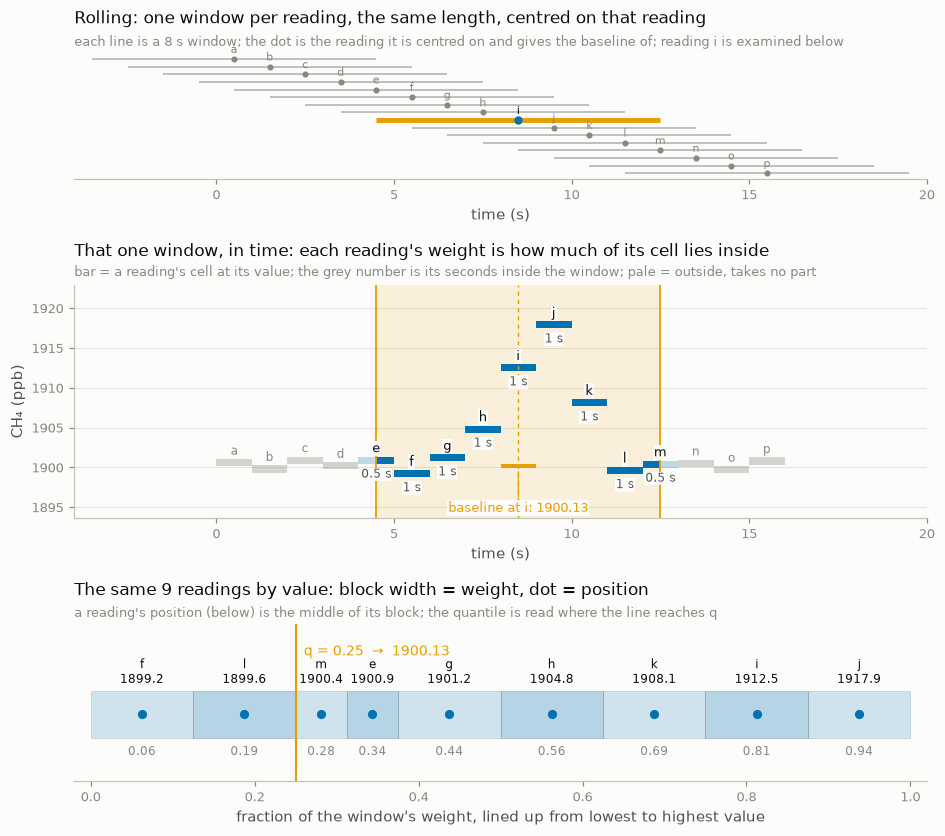

In [4]:
start_section("§1")
values = np.asarray(VALUES, dtype=float)
n = values.size
cells = uniform_cells("2026-06-15T10:00:00", CELL_S, n)
start_s = (cells.start_ns - cells.start_ns[0]) / SECOND
stop_s = start_s + CELL_S
middle_s = (start_s + stop_s) / 2
# The window centred on the examined reading, and each reading's overlap with it.
lo, hi = middle_s[CENTRE] - WINDOW_S / 2, middle_s[CENTRE] + WINDOW_S / 2
weights = np.clip(np.minimum(stop_s, hi) - np.maximum(start_s, lo), 0, None)
inside = weights > 0
by_hand = reference_weighted_quantile(values, weights, Q)
by_tsara = float(weighted_quantile(values, weights, [Q])[0])
rolled = rolling_quantile(cells, values, window_cells(cells, int(round(WINDOW_S * SECOND))), [Q])

names = [chr(ord("a") + k) for k in range(n)]
order = np.flatnonzero(inside)[np.argsort(values[inside], kind="stable")]
w = weights[order]
cumulative = np.cumsum(w)
positions = (cumulative - w / 2) / cumulative[-1]
print(
    f"window around reading {names[CENTRE]}: {lo:g} s to {hi:g} s, {inside.sum()} readings inside"
)
print(
    "weights (s):      " + ", ".join(f"{names[k]} {weights[k]:g}" for k in np.flatnonzero(inside))
)
print("by value:         " + ", ".join(f"{names[k]} {values[k]:.1f}" for k in order))
print("positions:        " + ", ".join(f"{p:.3f}" for p in positions))
print(f"quantile at q = {Q}: by hand {by_hand:.3f}, TSARA {by_tsara:.3f}")
if 0 < Q <= 0.5:  # the quantiles a baseline state takes
    needs = sweep(quantiles=(Q,)).min_readings_for(Q)  # §3's count rule, ceil(1/q)
    verdict = "report this" if inside.sum() >= needs else "leave this blank"
    print(
        f"the baseline state (§3) would {verdict}: {inside.sum()} readings in the window, "
        f"q = {Q:g} needs {needs}"
    )
else:
    print(f"(a baseline state takes quantiles in (0, 0.5]; q = {Q:g} is the definition only)")
check(
    "§1 TSARA's weighted quantile equals the one written from the definition",
    agree(by_tsara, by_hand),
)
check(
    "§1 rolling is this, at every reading: the engine's value at the examined reading is it",
    agree(rolled.values[CENTRE, 0], by_tsara),
)
equal = np.ones(n)
check(
    "§1 with equal weights it is numpy's Hazen rule, at every q",
    np.allclose(
        weighted_quantile(values, equal, [0.0, 0.1, 0.25, 0.5, 0.9, 1.0]),
        np.quantile(values, [0.0, 0.1, 0.25, 0.5, 0.9, 1.0], method="hazen"),
        rtol=1e-12,
    ),
)
check(
    "§1 the order of the readings does not matter",
    float(weighted_quantile(values[::-1], weights[::-1], [Q])[0]) == by_tsara,
)
check(
    "§1 a reading with no weight, or no value, takes no part",
    float(weighted_quantile(np.r_[values, 5000.0], np.r_[weights, 0.0], [Q])[0]) == by_tsara
    and float(weighted_quantile(np.r_[values, np.nan], np.r_[weights, 3.0], [Q])[0]) == by_tsara,
)

# Figure only from here: every reading's window; the examined window in time;
# its readings by value, with the walk to q.
fig, (ax0, ax1, ax2) = plt.subplots(
    3, 1, figsize=(10, 8.6), gridspec_kw={"height_ratios": [1.25, 2.3, 1.55], "hspace": 0.62}
)
span = (
    min(middle_s[0] - WINDOW_S / 2, start_s[0]) - 0.5,
    max(middle_s[-1] + WINDOW_S / 2, stop_s[-1]) + 0.5,
)
for k in range(n):
    here = k == CENTRE
    ax0.plot(
        [middle_s[k] - WINDOW_S / 2, middle_s[k] + WINDOW_S / 2],
        [k, k],
        color=C2 if here else MUTED,
        lw=3.2 if here else 1.2,
        alpha=1.0 if here else 0.55,
        solid_capstyle="butt",
    )
    ax0.plot(middle_s[k], k, "o", color=C1 if here else MUTED, ms=4.5 if here else 3)
    ax0.text(
        middle_s[k],
        k - 0.45,
        names[k],
        ha="center",
        va="bottom",
        fontsize=7.5,
        color=INK if here else MUTED,
    )
ax0.set_ylim(n - 0.3, -0.9)
ax0.set_yticks([])
ax0.set_xlim(*span)
ax0.spines["left"].set_visible(False)
finish(
    ax0,
    "Rolling: one window per reading, the same length, centred on that reading",
    f"each line is a {WINDOW_S:g} s window; the dot is the reading it is centred on and "
    f"gives the baseline of; reading {names[CENTRE]} is examined below",
    None,
    "time (s)",
    grid_axis=None,
)

ax1.axvspan(lo, hi, color=C2, alpha=0.13, lw=0)
ax1.axvline(middle_s[CENTRE], color=C2, lw=0.9, ls=(0, (3, 3)))
for edge in (lo, hi):
    ax1.axvline(edge, color=C2, lw=1.2)
bar = 0.9
for k in range(n):
    if not inside[k]:
        ax1.add_patch(
            Rectangle((start_s[k], values[k] - bar / 2), CELL_S, bar, color=MUTED, alpha=0.35, lw=0)
        )
        ax1.text(middle_s[k], values[k] + 1.0, names[k], ha="center", fontsize=8, color=MUTED)
        continue
    a, b = max(start_s[k], lo), min(stop_s[k], hi)
    ax1.add_patch(Rectangle((a, values[k] - bar / 2), b - a, bar, color=C1, lw=0))
    for piece in ((start_s[k], a), (b, stop_s[k])):  # the part of the cell outside the window
        if piece[1] > piece[0]:
            ax1.add_patch(
                Rectangle(
                    (piece[0], values[k] - bar / 2),
                    piece[1] - piece[0],
                    bar,
                    color=C1,
                    alpha=0.25,
                    lw=0,
                )
            )
    ax1.text(
        middle_s[k],
        values[k] + 1.0,
        names[k],
        ha="center",
        fontsize=8.5,
        color=INK,
        bbox={"facecolor": SURFACE, "edgecolor": "none", "pad": 0.6},
    )
    ax1.text(
        middle_s[k],
        values[k] - 2.2,
        f"{weights[k]:g} s",
        ha="center",
        fontsize=7.6,
        color=INK2,
        bbox={"facecolor": SURFACE, "edgecolor": "none", "pad": 0.6},
    )
ax1.plot(
    [start_s[CENTRE], stop_s[CENTRE]], [by_tsara, by_tsara], color=C2, lw=2.6, solid_capstyle="butt"
)
bottom = min(values.min(), by_tsara) - 5.5
ax1.annotate(
    f"baseline at {names[CENTRE]}: {by_tsara:.2f}",
    (middle_s[CENTRE], by_tsara - 0.3),
    xytext=(middle_s[CENTRE], bottom + 1.2),
    ha="center",
    va="center",
    fontsize=8.8,
    color=C2,
    arrowprops={"arrowstyle": "-", "color": C2, "lw": 0.8},
    bbox={"facecolor": SURFACE, "edgecolor": "none", "pad": 0.6},
)
ax1.set_xlim(*span)
ax1.set_ylim(bottom, values.max() + 5.0)
finish(
    ax1,
    "That one window, in time: each reading's weight is how much of its cell lies inside",
    "bar = a reading's cell at its value; the grey number is its seconds inside the window; "
    "pale = outside, takes no part",
    "CH₄ (ppb)",
    "time (s)",
)

left = np.r_[0.0, cumulative[:-1]] / cumulative[-1]
for j, k in enumerate(order):
    ax2.barh(
        0,
        w[j] / cumulative[-1],
        left=left[j],
        height=0.5,
        color=C1,
        alpha=0.18 + 0.1 * (j % 2),
        edgecolor=INK2,
        lw=0.6,
    )
    ax2.plot(positions[j], 0, "o", color=C1, ms=5)
    ax2.text(positions[j], 0.33, f"{names[k]}\n{values[k]:.1f}", ha="center", fontsize=8, color=INK)
    ax2.text(positions[j], -0.43, f"{positions[j]:.2f}", ha="center", fontsize=7.8, color=MUTED)
ax2.axvline(Q, color=C2, lw=1.4)
ax2.text(Q + 0.01, 0.62, f"q = {Q}  →  {by_tsara:.2f}", ha="left", color=C2, fontsize=9)
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(-0.7, 0.95)
ax2.set_yticks([])
ax2.spines["left"].set_visible(False)
finish(
    ax2,
    f"The same {inside.sum()} readings by value: block width = weight, dot = position",
    "a reading's position (below) is the middle of its block; the quantile is read where the "
    "line reaches q",
    None,
    "fraction of the window's weight, lined up from lowest to highest value",
    grid_axis=None,
)
plt.show()

**What to read off the output.** The top panel is what "rolling" means: the
same computation repeated with the window moved to the next reading, so
neighbouring windows share most of their readings. The middle panel is where
the weights come from: the two readings the window's edges cut through count
half a second each. On a record whose readings sit back to back, that is
always so when the window is an even number of cells long, as 2, 10 and
60 min windows are on 1 s or 2 s cells (a 2 min window on 1 s cells holds
119 whole readings and two halves). The bottom panel is the quantile: the
walk to *q* lands between two positions, and the answer is interpolated
between those two readings' *values*. The plume readings sit at the top of
the line, which is why a low quantile is a baseline.

Two consequences matter for the rest of the notebook. First, a *q*-quantile
is the value a fraction *q* of the air falls below, so a window of *N*
readings holds, on average, *N*·*q* readings below it; with fewer than about
1/*q* readings the window usually holds nothing that low, which is §3's
count rule. Second, a masked reading or one that does not touch the window
is simply absent, so blanks in a record do not move the quantile; they thin
the window.

**Try it.** `CENTRE = 0`: the first reading's window reaches before the record
starts and holds only its right half; nothing is padded. `WINDOW_S = 7.0`: an
odd number of cells, so the window's edges fall on cell boundaries and every
weight is a whole second. `Q = 0.0` gives the lowest reading and `Q = 1.0` the
highest, whatever the weights.

---
## 2. The baseline state on a campaign: what a window follows, and what it leaves

**The question.** `METHODS.md` §6.1 argues that there is no single true
baseline: a rolling low quantile over a window of length *w* follows everything
slower than about *w* and leaves what is shorter standing as enhancement. Is
that what the built state does, and does the baseline sit where the true
background is?

The campaign is §6.1's worked case, manufactured: a **landfill** whose plumes
last tens of minutes and a **gas line** whose blips last seconds, both on one
methane background the generator records at every instant
(`truth_background_ch4`). `baseline_state` in `src/tsara/baseline/state.py`
computes the baseline at every reading for every point of a window × quantile
sweep, the enhancement, and the sigmas of both, on the stream's own cells.

In [5]:
# ---- PARAMETERS (section 2) --------------------------------------------------
WINDOWS = ("2min", "20min", "2h")  # the sweep's windows, short -> long
QUANTILE = 0.05  # the quantile drawn and checked (one of the sweep's)
LANDFILL_SIGMA = "8min"  # how long a landfill plume lasts (Gaussian sigma)
BLIPS_PER_HOUR = 10.0  # how often the gas line's blips arrive
NOISE_PPB = 0.7  # the analyzer's white noise
VIEW_MINUTES = 150  # minutes of record drawn, around the largest landfill plume

state: {'time': 21600, 'baseline_window': 3, 'baseline_quantile': 1, 'nv': 2}
columns for ch4: ['baseline_ch4', 'ch4', 'coverage_window_ch4', 'enhancement_ch4', 'n_readings_window_ch4', 'sigma_rand_baseline_ch4']


  ✔ §2 the baseline at 2min is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 2min


  ✔ §2 the baseline at 20min is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 20min


  ✔ §2 the baseline at 2h is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 2h
  ✔ §2 the enhancement is the reading minus the baseline, blank where either is
  ✔ §2 enhancements are never clipped: noise below the baseline stays negative
  ✔ §2 the baseline carries no cell_methods; the enhancement inherits the reading's


  ✔ §2 in clean air the 2min baseline sits z_q·σ below the true background   [median -1.15 ppb, expected -1.15, over 7893 readings]


  ✔ §2 in clean air the 20min baseline sits z_q·σ below the true background   [median -1.19 ppb, expected -1.15, over 463 readings]


  (no plume-free 2h window in this record; lower BLIPS_PER_HOUR to see one)

share of the landfill's enhancement each baseline absorbs (median, where it adds over 20 ppb): 2min 0.97, 20min 0.47, 2h 0.02
  ✔ §2 the longest window absorbs less of the landfill than the shortest   [0.97, 0.47, 0.02]


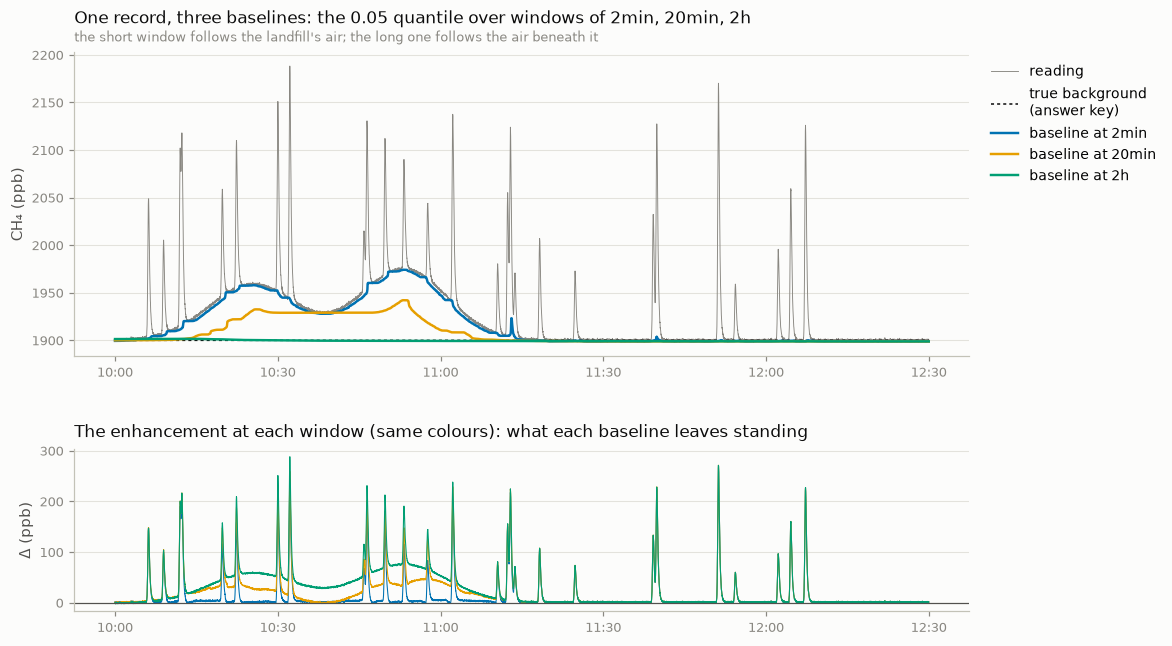

In [6]:
start_section("§2")
data = landfill_campaign(
    landfill_sigma=LANDFILL_SIGMA, blips_per_hour=BLIPS_PER_HOUR, noise_ppb=NOISE_PPB
)
stream = data.streams["analyzer"]
settings = sweep(windows=WINDOWS, quantiles=(QUANTILE,))
state = baseline_state(measured(stream), instrument="analyzer", baseline=settings)
truth = stream["truth_background_ch4"].values
readings = stream["ch4"].values
clock = stream["time"].values
baseline = state["baseline_ch4"]  # dims (time, baseline_window, baseline_quantile)
enhancement = state["enhancement_ch4"]
print(f"state: {dict(state.sizes)}")
print(f"columns for ch4: {sorted(v for v in state.data_vars if str(v).endswith('ch4'))}")

# The baseline at each window equals the definition applied window by window,
# blanked where the window holds fewer readings than the count rule asks.
cells = cells_of(stream)
minimum = settings.min_readings_for(QUANTILE)
for w, window in enumerate(WINDOWS):
    want, count, coverage = reference_rolling(
        cells, readings, pd.Timedelta(window).total_seconds(), QUANTILE, min_readings=minimum
    )
    got = baseline.values[:, w, 0]
    check(f"§2 the baseline at {window} is the definition, window by window", agree(got, want))
    check(
        f"§2 its window count and coverage are the definition's, at {window}",
        same(state["n_readings_window_ch4"].values[:, w], count)
        and np.allclose(state["coverage_window_ch4"].values[:, w], coverage),
    )
check(
    "§2 the enhancement is the reading minus the baseline, blank where either is",
    same(enhancement.values, readings[:, None, None] - baseline.values),
)
check(
    "§2 enhancements are never clipped: noise below the baseline stays negative",
    np.nanmin(enhancement.values) < 0,
)
check(
    "§2 the baseline carries no cell_methods; the enhancement inherits the reading's",
    "cell_methods" not in baseline.attrs
    and enhancement.attrs.get("cell_methods") == stream["ch4"].attrs.get("cell_methods"),
)

# Against the truth: where the air is plume-free, a low quantile of noise sits a
# known offset below the background (-z_q sigma for Gaussian noise).
quiet = stream["truth_enhancement_ch4"].values < 0.1 * NOISE_PPB
offset_expected = norm.ppf(QUANTILE) * NOISE_PPB
for w, window in enumerate(WINDOWS):
    gap = baseline.values[:, w, 0] - truth
    hold = np.isfinite(gap) & quiet
    # Only windows that are themselves quiet: a plume anywhere in a long window
    # raises its quantile, so the offset is exact only for clean windows.
    top_of_window = rolling_quantile(
        cells,
        stream["truth_enhancement_ch4"].values,
        window_cells(cells, pd.Timedelta(window).value),
        [0.99],
    ).values[:, 0]
    clean_window = top_of_window < 0.1 * NOISE_PPB
    hold &= clean_window
    if hold.sum() > 50:
        check(
            f"§2 in clean air the {window} baseline sits z_q·σ below the true background",
            abs(np.median(gap[hold]) - offset_expected) < 0.25 * NOISE_PPB,
            f"median {np.median(gap[hold]):+.2f} ppb, expected {offset_expected:+.2f}, "
            f"over {hold.sum()} readings",
        )
    else:
        print(f"  (no plume-free {window} window in this record; lower BLIPS_PER_HOUR to see one)")

# What each window takes into its baseline. The landfill's own enhancement is
# rebuilt from the answer key's events (a Gaussian of known width); the share
# absorbed is (baseline - true background - the quantile offset) over it, where
# the landfill adds more than 20 ppb.
events = data.ground_truth.to_frame()
landfills = events[events["source_name"] == "landfill"]
seconds = (clock - clock[0]) / np.timedelta64(1, "s")
width_s = pd.Timedelta(LANDFILL_SIGMA).total_seconds()
landfill_air = np.zeros(clock.size)
for _, event in landfills.iterrows():
    peak_s = (np.datetime64(pd.Timestamp(event["peak_time"])) - clock[0]) / np.timedelta64(1, "s")
    landfill_air += event["true_amplitude"] * np.exp(-0.5 * ((seconds - peak_s) / width_s) ** 2)
under = landfill_air > 20.0
if under.sum() > 50:
    shares = [
        float(
            np.nanmedian(
                (baseline.values[under, w, 0] - truth[under] - offset_expected)
                / landfill_air[under]
            )
        )
        for w in range(len(WINDOWS))
    ]
    print(
        "\nshare of the landfill's enhancement each baseline absorbs (median, where it adds "
        "over 20 ppb): "
        + ", ".join(f"{window} {share:.2f}" for window, share in zip(WINDOWS, shares))
    )
    check(
        "§2 the longest window absorbs less of the landfill than the shortest",
        shares[-1] < shares[0],
        ", ".join(f"{share:.2f}" for share in shares),
    )
else:
    print(
        "  (no landfill air above 20 ppb in this record: raise the landfill to measure absorption)"
    )

# Figure only from here. The view is chosen from the answer key: around the
# largest landfill plume, so the figure shows the case it is about, and kept
# inside the record.
centre = pd.Timestamp(
    landfills.sort_values("true_amplitude").iloc[-1]["peak_time"]
    if len(landfills)
    else clock[len(clock) // 2]
)
half = pd.Timedelta(minutes=VIEW_MINUTES / 2)
first, last = pd.Timestamp(clock[0]), pd.Timestamp(clock[-1])
view_start = min(max(centre - half, first), max(last - 2 * half, first))
view = (view_start, min(view_start + 2 * half, last))
inside = (clock >= np.datetime64(view[0])) & (clock <= np.datetime64(view[1]))
fig, (ax, axd) = plt.subplots(
    2, 1, figsize=(10.5, 6.6), gridspec_kw={"height_ratios": [3.0, 1.6], "hspace": 0.4}
)
t, x = break_gaps(clock[inside], readings[inside])
ax.plot(t, x, color=MUTED, lw=0.6, label="reading")
ax.plot(
    clock[inside],
    truth[inside],
    color=INK,
    lw=1.0,
    ls=(0, (2, 2)),
    label="true background\n(answer key)",
)
for w, (window, colour) in enumerate(zip(WINDOWS, (C1, C2, C3))):
    ax.plot(
        clock[inside],
        baseline.values[inside, w, 0],
        color=colour,
        lw=1.6,
        label=f"baseline at {window}",
    )
finish(
    ax,
    f"One record, three baselines: the {QUANTILE:g} quantile over windows of {', '.join(WINDOWS)}",
    "the short window follows the landfill's air; the long one follows the air beneath it",
    "CH₄ (ppb)",
    None,
)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
hhmm(ax)
for w, (window, colour) in enumerate(zip(WINDOWS, (C1, C2, C3))):
    t, d = break_gaps(clock[inside], enhancement.values[inside, w, 0])
    axd.plot(t, d, color=colour, lw=0.7)
axd.axhline(0, color=INK2, lw=0.8)
finish(
    axd,
    "The enhancement at each window (same colours): what each baseline leaves standing",
    None,
    "Δ (ppb)",
    None,
)
hhmm(axd)
plt.show()

**What to read off the output.** The upper panel is the argument of §6.1 drawn.
Under the landfill plume the 2 min baseline (blue) climbs with the plume: it
follows everything slower than about two minutes, so the landfill's air *is*
its background, and its enhancement (lower panel, blue) shows only the blips.
The 2 h baseline (green) stays with the true background under the whole plume,
so its enhancement shows the landfill with the blips riding on top. The 20 min
baseline is partly absorbed by a plume of comparable length, which is why the
window is a sweep dimension rather than a setting to get right. The printed
shares put numbers on it: nearly all of the landfill at 2 min, about half at
20 min, almost none at 2 h. The same happens to short plumes that crowd
together: where several blips arrive within a couple of minutes, the 2 min
baseline lifts with them, because a cluster that fills the window is absorbed
like one long plume.

In clean stretches every baseline sits a little *below* the true background:
a 5th percentile of noise is 1.64σ under its mean. That offset is the reason
detection (Phase 6) corrects its thresholds by the quantile, and the checks
above confirm it is exactly *z_q*σ where the window is plume-free.

**Try it.** `VIEW_MINUTES = 360` draws the whole record. `LANDFILL_SIGMA =
"20min"`: the 20 min baseline now absorbs most of the landfill too (its share
rises to about 0.8), and only the 2 h window still sees it as a plume.
`BLIPS_PER_HOUR = 0`: the short window's enhancement is pure noise, centred
about 1.15 ppb above zero by the quantile offset, and the quiet-air checks
find clean windows at every length. `QUANTILE = 0.5`: the median sits on the
background in clean air (offset 0) and inside the plumes of every window that
is more than half plume.

---
## 3. The count rule, the edge of a record, and what a blank records

**The question.** A 5th percentile of three readings is not a background. When
does TSARA refuse to report one, what does it say, and what happens at the
start of a record, where a centred window is half empty?

**The rule** (`METHODS.md` §6.4) is a **count**. A 1st percentile is the value
one reading in a hundred falls below. In a hundred readings, on average one
falls that low, so the window can show where the 1st percentile is. In eleven
readings, on average 0.11 do, and 90 % of the time none do: the window holds
nothing that low, and any answer from it is too high. So the default count,
⌈1/*q*⌉, is the number of readings at which, on average, one reading falls
below the quantile asked for: 100 for the 1st percentile, 20 for the 5th, 10
for the 10th. A thinner window is blank at that quantile, with the reason
recorded. There is no padding and no special case at the edge of a record: the
first window holds its right half, its count and coverage say so, and the same
rule decides. A sweep point blank at every reading is named in one warning per
stream. The instrument here reports 60 s means, the shape of a stationary
suite, so a two-minute window holds three of its readings at most.

In [7]:
# ---- PARAMETERS (section 3) --------------------------------------------------
WINDOWS = ("2min", "10min", "60min")  # the sweep's windows
QUANTILES = (0.01, 0.05, 0.10)  # the sweep's quantiles: they need 100, 20 and 10 readings
MIN_READINGS = None  # None = ceil(1/q) per quantile; an integer applies to every quantile
DURATION = "6h"  # length of the record

In [8]:
start_section("§3")
data = minute_campaign(duration=DURATION)
stream = measured(data.streams["suite"])
settings = sweep(windows=WINDOWS, quantiles=QUANTILES, min_readings=MIN_READINGS)
minimum = [settings.min_readings_for(q) for q in QUANTILES]

# The warning is part of what this section shows: capture it and print it.
captured = []
handler = logging.Handler()
handler.emit = lambda record: captured.append(record.getMessage())
logging.getLogger("tsara.baseline.state").addHandler(handler)
try:
    state = baseline_state(stream, instrument="suite", baseline=settings)
finally:
    logging.getLogger("tsara.baseline.state").removeHandler(handler)
print(f"readings: {stream.sizes['time']} minute means; a window of 2 min holds at most 3 of them\n")
print("the warning, verbatim:")
print("  " + "\n  ".join(captured) if captured else "  (none)")

counts = state["n_readings_window_ch4"].values  # (time, window)
blank = np.isnan(state["baseline_ch4"].values)  # (time, window, quantile)
recorded = (
    state["baseline_ch4"]
    .attrs["tsara_baseline_blank_fraction"]
    .reshape(len(WINDOWS), len(QUANTILES))
)
print(
    f"\n{'window':>8} "
    + " ".join(f"q={q:<5g}" for q in QUANTILES)
    + "   readings per window (min / median / max)"
)
print(f"{'needs':>8} " + " ".join(f"{m:<7d}" for m in minimum))
for w, window in enumerate(WINDOWS):
    shares = " ".join(f"{recorded[w, j]:<7.0%}" for j in range(len(QUANTILES)))
    spread = f"{counts[:, w].min()} / {int(np.median(counts[:, w]))} / {counts[:, w].max()}"
    print(f"{window:>8} {shares}   {spread}   blank share per quantile")

# Checks against the definition, window by window.
cells = cells_of(stream)
readings = stream["ch4"].values
for w, window in enumerate(WINDOWS):
    for j, q in enumerate(QUANTILES):
        want, count, coverage = reference_rolling(
            cells, readings, pd.Timedelta(window).total_seconds(), q, min_readings=minimum[j]
        )
        check(
            f"§3 blank exactly where the window has under {minimum[j]} readings: {window}, q={q:g}",
            agree(state["baseline_ch4"].values[:, w, j], want),
        )
check(
    "§3 the recorded blank fraction per sweep point is the share of readings left blank",
    np.allclose(recorded, blank.mean(axis=0)),
)
fully = [
    f"{window}/{q:g}"
    for w, window in enumerate(WINDOWS)
    for j, q in enumerate(QUANTILES)
    if recorded[w, j] == 1.0
]
named = [
    point
    for point in (f"{window}/{q:g}" for window in WINDOWS for q in QUANTILES)
    if any(f"{sep}{point} (" in message for message in captured for sep in (": ", "; "))
]
check(
    "§3 the warning names every sweep point blank at every reading, and no other",
    fully == named,
    f"{len(fully)} point(s): {', '.join(fully) or 'none'}",
)
# The edge: the first window at the longest window holds its right half.
longest = len(WINDOWS) - 1
longest_s = pd.Timedelta(WINDOWS[longest]).total_seconds()
_, first_count, first_coverage = reference_rolling(
    cells, readings, longest_s, QUANTILES[-1], min_readings=1
)
edge_coverage = state["coverage_window_ch4"].values[0, longest]
check(
    f"§3 at the record's edge the {WINDOWS[longest]} window holds its right half: no padding",
    abs(edge_coverage - 0.5) < 1.5 * 60 / longest_s and counts[0, longest] == first_count[0],
    f"coverage {edge_coverage:.3f}, {counts[0, longest]} readings",
)

2026-09-30 11:45:48 | WARNING  | tsara.baseline.state | Baseline state of 'suite': sweep points blank at every reading -- ch4: 2min/0.01 (windows held at most 3 readings; 100 needed); 2min/0.05 (windows held at most 3 readings; 20 needed); 2min/0.1 (windows held at most 3 readings; 10 needed); 10min/0.01 (windows held at most 11 readings; 100 needed); 10min/0.05 (windows held at most 11 readings; 20 needed); 60min/0.01 (windows held at most 61 readings; 100 needed). A window holding fewer readings than the count rule asks (METHODS 6.4), or a reading at least twice as wide as the window (6.3), leaves that point blank with the reason recorded; choose a longer window, a lower count, or another baseline method (6.5) for these variables.


readings: 360 minute means; a window of 2 min holds at most 3 of them

the warning, verbatim:
  Baseline state of 'suite': sweep points blank at every reading -- ch4: 2min/0.01 (windows held at most 3 readings; 100 needed); 2min/0.05 (windows held at most 3 readings; 20 needed); 2min/0.1 (windows held at most 3 readings; 10 needed); 10min/0.01 (windows held at most 11 readings; 100 needed); 10min/0.05 (windows held at most 11 readings; 20 needed); 60min/0.01 (windows held at most 61 readings; 100 needed). A window holding fewer readings than the count rule asks (METHODS 6.4), or a reading at least twice as wide as the window (6.3), leaves that point blank with the reason recorded; choose a longer window, a lower count, or another baseline method (6.5) for these variables.

  window q=0.01  q=0.05  q=0.1     readings per window (min / median / max)
   needs 100     20      10     
    2min 100%    100%    100%      2 / 3 / 3   blank share per quantile
   10min 100%    100%    2%        

**What to read off the output.** The table is the state's own record,
`tsara_baseline_blank_fraction`, one number per sweep point. At 2 min every
point is blank for every reading: three minute means cannot make a 10th
percentile, let alone a 1st. At 10 min the window holds eleven readings (nine
whole minutes and the two half-minutes its edges cut through, as §1 drew), so
only *q* = 0.10 (ten needed) is reported; at 60 min the 1st percentile (a
hundred needed) is still blank while the others are fine. The warning names
exactly the points that are blank everywhere, gives each the rule that blanked
it with the most readings any window held beside the count it needed, and says
what to do: a longer window, a lower count, or another method (§5).

The edge: the first 60 min window holds 31 readings, not 61, and covers half
the window. Nothing was padded or invented; the rule simply decides on what is
there, which for the 60 min window at *q* = 0.05 is still enough.

**Try it.** `MIN_READINGS = 5`: the 10 min window is now reported at every
quantile, and the warning shrinks to the 2 min points. `WINDOWS = ("2min",
"10min", "30min")`: a 30 min window holds 31 readings in the middle of the
record and 16 at its edges, so the *q* = 0.05 point (twenty needed) goes blank
at both ends, a few percent of readings, and is not in the warning, since it
is not blank everywhere.

---
## 4. The width rule: a reading is not stood on a window narrower than half of it

**The question.** What does the width rule of `METHODS.md` §6.3, the same
`COPY_RATIO = 2` every join holds to, protect against that the count rule does
not?

A window narrower than half a reading would take its value from a mean over a
much longer interval and call it the local background: the same operation as
copying a 60 s mean onto 1 s cells, which the join refuses (notebook 04, §4).
When readings sit back to back, the count rule always refuses such a window
first: a window narrower than a reading, centred on it, touches only that one
reading, and the count is never below two. The width rule is the protection
when readings **overlap**: a running mean logged more often than its length.
Below, a 60 s running mean is logged every second. A 30 s window touches
about ninety readings, plenty for the 5th percentile's twenty, and every one of
them describes a minute of air, twice the window.

In [9]:
# ---- PARAMETERS (section 4) --------------------------------------------------
MEAN_S = 60.0  # how long each logged mean is
EVERY_S = 1.0  # how often one is logged: overlapping cells when shorter than MEAN_S
WINDOW = "30s"  # the window the width rule is asked about
QUANTILE = 0.05  # the quantile asked for; its default count is ceil(1/q)

In [10]:
start_section("§4")
n = int(round(30 * 60 / EVERY_S))  # half an hour of readings
rng = np.random.default_rng(4)
starts = pd.Timestamp("2026-06-18T12:00:00").value + np.arange(n, dtype=np.int64) * int(
    EVERY_S * SECOND
)
running = make_stream(
    starts,
    starts + int(MEAN_S * SECOND),
    {"ch4": 1900 + rng.normal(0, 0.4, n)},
    cell_methods="time: mean",
)
settings = sweep(windows=(WINDOW, "10min"), quantiles=(QUANTILE,))
needs = settings.min_readings_for(QUANTILE)
captured = []
handler = logging.Handler()
handler.emit = lambda record: captured.append(record.getMessage())
logging.getLogger("tsara.baseline.state").addHandler(handler)
try:
    state = baseline_state(running, instrument="running", baseline=settings)
finally:
    logging.getLogger("tsara.baseline.state").removeHandler(handler)
ratio = MEAN_S / pd.Timedelta(WINDOW).total_seconds()
too_wide = state["baseline_ch4"].attrs["tsara_baseline_too_wide_fraction"]
counts = state["n_readings_window_ch4"].values
print(f"a {MEAN_S:g} s mean logged every {EVERY_S:g} s, under a {WINDOW} window:")
print(f"  the reading is {ratio:g} x as wide as the window")
print(
    f"  readings in the window: {counts[:, 0].min()} to {counts[:, 0].max()} "
    f"(q = {QUANTILE:g} needs {needs})"
)
print(f"  share of windows failing the width rule, per window: {too_wide.tolist()}")
blank_share = np.isnan(state["baseline_ch4"].values[:, :, 0]).mean(axis=0).round(3).tolist()
print(f"  blank share, per window: {blank_share}")
print("the warning, verbatim:")
print("  " + "\n  ".join(captured) if captured else "  (none)")

blank_short = np.isnan(state["baseline_ch4"].values[:, 0, 0])
if ratio >= 2.0:
    if (counts[:, 0] >= needs).all():
        decided = "the count rule passed at every window; the width rule refused"
    elif (counts[:, 0] < needs).all():
        decided = "the count rule refused first; the width rule would have too"
    else:
        decided = "some windows failed the count, the rest the width rule"
    check(
        f"§4 with the reading {ratio:g} x the window, every {WINDOW} window is blank, "
        "and recorded as too wide",
        blank_short.all() and too_wide[0] == 1.0,
        decided,
    )
    if (counts[:, 0] >= needs).all():
        check(
            "§4 where only the width rule could refuse, the warning names the width rule",
            any("as wide as itself" in message for message in captured)
            and not any(f"{WINDOW}/{QUANTILE:g} (windows held" in m for m in captured),
        )
else:
    check(
        f"§4 with the reading {ratio:g} x the window (under 2), {WINDOW} is not refused for width",
        too_wide[0] == 0.0,
    )
check(
    "§4 a 10 min window on the same readings is never too wide, and blank only where it holds "
    "too few readings",
    too_wide[1] == 0.0
    and same(np.isnan(state["baseline_ch4"].values[:, 1, 0]), counts[:, 1] < needs),
)

2026-09-30 11:45:49 | WARNING  | tsara.baseline.state | Baseline state of 'running': sweep points blank at every reading -- ch4: 30s/0.05 (every window held a reading at least 2x as wide as itself). A window holding fewer readings than the count rule asks (METHODS 6.4), or a reading at least twice as wide as the window (6.3), leaves that point blank with the reason recorded; choose a longer window, a lower count, or another baseline method (6.5) for these variables.


a 60 s mean logged every 1 s, under a 30s window:
  the reading is 2 x as wide as the window
  readings in the window: 45 to 89 (q = 0.05 needs 20)
  share of windows failing the width rule, per window: [1.0, 0.0]
  blank share, per window: [1.0, 0.0]
the warning, verbatim:
  Baseline state of 'running': sweep points blank at every reading -- ch4: 30s/0.05 (every window held a reading at least 2x as wide as itself). A window holding fewer readings than the count rule asks (METHODS 6.4), or a reading at least twice as wide as the window (6.3), leaves that point blank with the reason recorded; choose a longer window, a lower count, or another baseline method (6.5) for these variables.
  ✔ §4 with the reading 2 x the window, every 30s window is blank, and recorded as too wide   [the count rule passed at every window; the width rule refused]
  ✔ §4 where only the width rule could refuse, the warning names the width rule
  ✔ §4 a 10 min window on the same readings is never too wide, and bla

**What to read off the output.** The 30 s windows hold about ninety
overlapping readings each, so the count rule is satisfied, and they are still
blank: every one of them held a reading twice its own width, the state records
that as `tsara_baseline_too_wide_fraction = 1.0` for that window, and the
warning names the width rule as the reason. At 10 min the same readings are a
tenth of the window and the baseline is reported. The line is exactly 2, as it
is for a join, and the reason is the same: a value averaged over an interval is
not the value at a fraction of it. TSARA sets a reading's width to its file's
cadence unless a manifest or a stop column says otherwise, so readings
normally sit back to back and the count rule does this job; the width rule is
there for the logger that writes running means.

**Try it.** `WINDOW = "45s"`: the reading is 1.33 × the window, below the line,
so the width rule allows it; what the state reports is then a baseline built
from readings wider than the window, which is *narrowing* as notebook 04 §4
defines it. `EVERY_S = 60`: the readings sit back to back, a 30 s window holds
one reading, and the count rule refuses first, as the check's note says.

---
## 5. A sparse instrument adopts a dense one's baseline: `from_field` as three calls

**The question.** A canister fills for fifteen seconds every nine minutes. At
the windows where a 1 s analyzer has a baseline it holds one fill (`METHODS.md`
§6.5 measured 54 % of 10 min windows on the real archive). What stands in?

Your decision: options, not one rule. `from_field` adopts **another
instrument's baseline of the same field**, joined onto this instrument's cells:
the atmosphere has one benzene background, and the PTR-MS samples it every
second beside the canister. Because the stages of TSARA hand each other
Datasets and never import each other, this is three calls, shown below one by
one: roll the donor; join its swept baseline onto the adopter's cells with the
ordinary binner (which since Phase 5 averages every version of a swept variable
at once); roll the adopter with the product handed in as `provided=`. The
adopter refuses anything that is not that join: a product the binner did not
make, one on other cells, one at another sweep, or one that is not the donor's
baseline of this field.

One thing comes along that is easy to miss: a low quantile of noisy readings
sits about *z_q*·σ below the true background (§2), with σ the **donor's**
noise. The adopted baseline brings that offset with it, so the quieter
canister's enhancement is lifted by the PTR's noise, not its own.

In [11]:
# ---- PARAMETERS (section 5) --------------------------------------------------
WINDOWS = ("10min", "60min")  # the sweep's windows
QUANTILE = 0.05  # the sweep's one quantile
FILL_EVERY = "530s"  # how often the canister fills (the archive's median)
FILL_WIDTH = "15s"  # how long a fill lasts
PTR_NOISE_PPB = 0.02  # the dense analyzer's noise (benzene, ppb); the canister's is 0.01

2026-09-30 11:45:49 | WARNING  | tsara.baseline.state | Baseline state of 'iwas': sweep points blank at every reading -- benzene_can: 10min/0.05 (windows held at most 2 readings; 20 needed); 60min/0.05 (windows held at most 7 readings; 20 needed). A window holding fewer readings than the count rule asks (METHODS 6.4), or a reading at least twice as wide as the window (6.3), leaves that point blank with the reason recorded; choose a longer window, a lower count, or another baseline method (6.5) for these variables.


ptr: 28800 readings at 1 s;  iwas: 55 fills of 15s every 530s
the canister's own rolling quantile is blank at [1.0, 1.0] of its fills, per window (it needs 20 fills in a window)



adopted baseline: method from_field, from ptr, the join's record straddled / 880 readings
  ✔ §5 the adopted baseline is the donor's, joined onto the canister's cells, exactly
  ✔ §5 the adopted baseline carries the join's record and names the donor
  ✔ §5 the canister's own rolling quantile is blank exactly where its window holds too few fills
  ✔ §5 the canister's enhancement is its fill minus the adopted baseline

over the 22 fills in clean air, the canister's 60min enhancement is +0.031 ppb; the PTR's offset predicts +0.033
  ✔ §5 in clean air the canister's enhancement is the donor's quantile offset   [+0.031 ppb against +0.033]

without provided=, the adopter says:
  'benzene_can' on 'iwas' adopts its baseline from 'ptr' (from_field), and no product was provided. Roll the donor stream first, join its baseline onto this stream's cells with tsara.align.bin_streams_onto_cells(donor_state, target=this stream's cells), and pass the result as provided={'benzene_can': joined}.
  ✔ §5 w

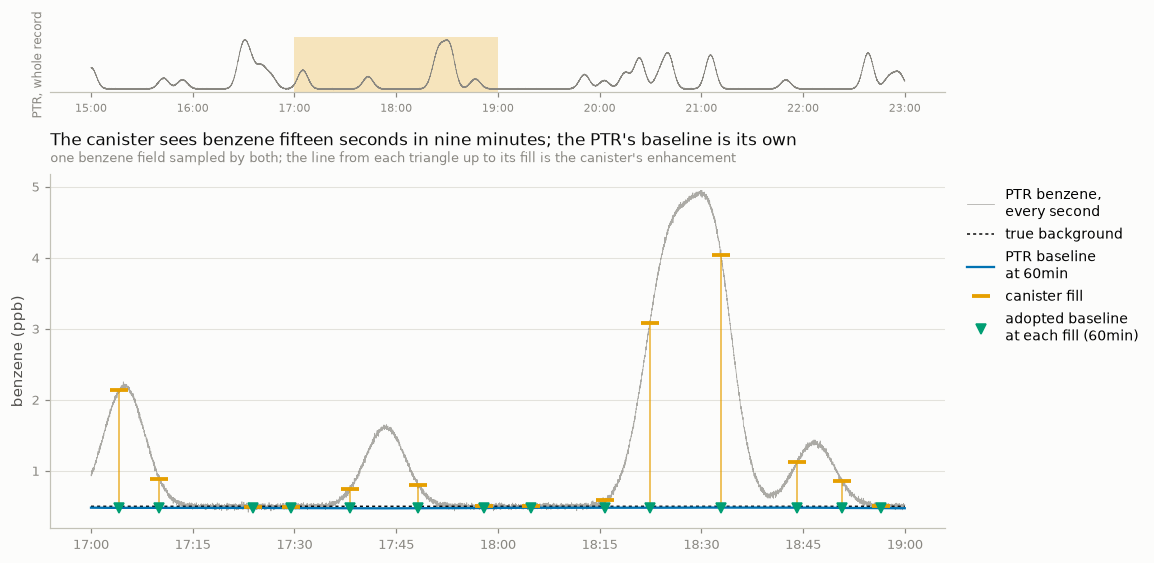

In [12]:
start_section("§5")
data = canister_campaign(fill_every=FILL_EVERY, fill_width=FILL_WIDTH, ptr_noise_ppb=PTR_NOISE_PPB)
ptr, iwas = measured(data.streams["ptr"]), measured(data.streams["iwas"])
settings = sweep(
    windows=WINDOWS,
    quantiles=(QUANTILE,),
    methods={"iwas.benzene_can": {"method": "from_field", "instrument": "ptr"}},
)
needs = settings.min_readings_for(QUANTILE)
print(
    f"ptr: {ptr.sizes['time']} readings at 1 s;  "
    f"iwas: {iwas.sizes['time']} fills of {FILL_WIDTH} every {FILL_EVERY}"
)

# What the canister can do on its own.
own = baseline_state(
    iwas, instrument="iwas", baseline=sweep(windows=WINDOWS, quantiles=(QUANTILE,))
)
own_blank = own["baseline_benzene_can"].attrs["tsara_baseline_blank_fraction"]
print(
    f"the canister's own rolling quantile is blank at {np.round(own_blank, 3).tolist()} of its "
    f"fills, per window (it needs {needs} fills in a window)"
)

# Call 1: roll the donor.
donor = baseline_state(ptr, instrument="ptr", baseline=settings)
# Call 2: join the donor's swept baseline onto the adopter's cells.
joined = bin_streams_onto_cells(
    {"ptr": donor}, stream_cells(iwas, "iwas"), [("ptr", "baseline_benzene")]
)
# Call 3: roll the adopter with the product provided.
adopter = baseline_state(
    iwas, instrument="iwas", baseline=settings, provided={"benzene_can": joined}
)
base = adopter["baseline_benzene_can"]
print(
    f"\nadopted baseline: method {base.attrs['tsara_baseline_method']}, "
    f"from {base.attrs['tsara_baseline_from']}, the join's record "
    f"{base.attrs['tsara_support_transform']} / {base.attrs['tsara_n_readings']} readings"
)

check(
    "§5 the adopted baseline is the donor's, joined onto the canister's cells, exactly",
    same(base.values, joined["baseline_benzene"].values),
)
check(
    "§5 the adopted baseline carries the join's record and names the donor",
    base.attrs["tsara_baseline_from"] == "ptr" and "tsara_support_transform" in base.attrs,
)
check(
    "§5 the canister's own rolling quantile is blank exactly where its window holds too few fills",
    same(
        np.isnan(own["baseline_benzene_can"].values[:, :, 0]),
        own["n_readings_window_benzene_can"].values < needs,
    ),
)
check(
    "§5 the canister's enhancement is its fill minus the adopted baseline",
    same(
        adopter["enhancement_benzene_can"].values,
        iwas["benzene_can"].values[:, None, None] - base.values,
    ),
)

# Against the answer key: what the adoption hands the canister. In clean air a
# low quantile of the PTR's readings sits about z_q times the PTR's noise below
# the background, so the canister's enhancement there is lifted by that much.
fill_truth = bin_streams_onto_cells(
    {"ptr": data.streams["ptr"]}, stream_cells(iwas, "iwas"), [("ptr", "truth_enhancement_benzene")]
)["truth_enhancement_benzene"].values
clean = fill_truth < 0.01
if clean.sum() >= 5:
    lifted = float(np.nanmedian(adopter["enhancement_benzene_can"].values[clean, -1, 0]))
    predicted = -norm.ppf(QUANTILE) * PTR_NOISE_PPB
    print(
        f"\nover the {clean.sum()} fills in clean air, the canister's {WINDOWS[-1]} enhancement is "
        f"{lifted:+.3f} ppb; the PTR's offset predicts {predicted:+.3f}"
    )
    check(
        "§5 in clean air the canister's enhancement is the donor's quantile offset",
        abs(lifted - predicted) <= 0.5 * abs(predicted) + 0.01,  # 0.01 ppb: the canister's noise
        f"{lifted:+.3f} ppb against {predicted:+.3f}",
    )
else:
    print("  (fewer than five fills in clean air: fewer plumes would show the offset)")

# The refusals: what the adopter will not accept as a baseline.
try:
    baseline_state(iwas, instrument="iwas", baseline=settings)
except TsaraBaselineError as error:
    print(f"\nwithout provided=, the adopter says:\n  {error}")
    check(
        "§5 without a provided product the adopter refuses and names the three calls",
        "bin_streams_onto_cells" in str(error) and "provided=" in str(error),
    )
elsewhere = bin_streams_onto_cells(
    {"ptr": donor},
    uniform_cells(iwas["time"].values[0], 15.0, len(iwas["time"])),
    [("ptr", "baseline_benzene")],
)
try:
    baseline_state(iwas, instrument="iwas", baseline=settings, provided={"benzene_can": elsewhere})
    check("§5 a product on other cells is refused", False)
except TsaraBaselineError as error:
    check(
        "§5 a product on other cells is refused",
        "does not sit on this stream's cells" in str(error),
    )

# Figure only from here. A fill is fifteen seconds on a two-hour axis, so each is
# drawn as one mark at its midpoint, its adopted baseline below it, and the line
# between them is its enhancement.
clock = ptr["time"].values
start = pd.Timestamp(clock[0])
view = (start + pd.Timedelta(hours=2), start + pd.Timedelta(hours=4))
inside = (clock >= np.datetime64(view[0])) & (clock < np.datetime64(view[1]))
fig, (top, ax) = plt.subplots(
    2, 1, figsize=(10.5, 5.8), gridspec_kw={"height_ratios": [0.5, 3.2], "hspace": 0.4}
)
overview_strip(top, clock, ptr["benzene"].values, view, "PTR, whole record")
t, x = break_gaps(clock[inside], ptr["benzene"].values[inside])
ax.plot(t, x, color=MUTED, lw=0.5, alpha=0.7, label="PTR benzene,\nevery second")
ax.plot(
    clock[inside],
    data.streams["ptr"]["truth_background_benzene"].values[inside],
    color=INK,
    lw=1.0,
    ls=(0, (2, 2)),
    label="true background",
)
ax.plot(
    clock[inside],
    donor["baseline_benzene"].values[inside, -1, 0],
    color=C1,
    lw=1.5,
    label=f"PTR baseline\nat {WINDOWS[-1]}",
)
fill_mid = iwas["time"].values
fill_in = (fill_mid >= np.datetime64(view[0])) & (fill_mid < np.datetime64(view[1]))
fill_values = iwas["benzene_can"].values[fill_in]
adopted = base.values[fill_in, -1, 0]
ax.vlines(fill_mid[fill_in], adopted, fill_values, color=C2, lw=1.0, alpha=0.8)
ax.plot(fill_mid[fill_in], fill_values, "_", color=C2, ms=12, mew=2.5, label="canister fill")
ax.plot(
    fill_mid[fill_in],
    adopted,
    "v",
    color=C3,
    ms=6,
    label=f"adopted baseline\nat each fill ({WINDOWS[-1]})",
)
finish(
    ax,
    "The canister sees benzene fifteen seconds in nine minutes; the PTR's baseline is its own",
    "one benzene field sampled by both; the line from each triangle up to its fill is the "
    "canister's enhancement",
    "benzene (ppb)",
    None,
)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
hhmm(ax)
plt.show()

**What to read off the output.** The canister's own rolling quantile is blank
wherever its window holds fewer than the twenty fills a 5th percentile needs,
which at these windows is everywhere, and the record says so rather than
reporting a baseline made of one fill. After the three calls each fill
(amber mark) has a baseline (green triangle) that is the PTR's 60 min baseline
averaged over that fill's fifteen seconds, and the line up to the fill is the
enhancement. The join's record is `straddled`: each fill touches sixteen of the
PTR's 1 s readings, the two at its ends only in part.

In clean air the enhancement is not zero but the PTR's quantile offset,
predicted and measured above. That is the price of adopting another
instrument's baseline: the offset is the donor's, and detection (Phase 6) has
to correct it with the donor's noise, not the canister's (`METHODS.md` §6.5,
§6.8). On the 2024-07-18 drive the same offset is about 0.05 ppb on every fill.

The refusals printed above are the point of the three-call design: the
adopter checks what it is handed rather than trusting it, so a product built
on other cells, at another sweep, or from another field cannot be adopted by
accident.

**Try it.** `FILL_EVERY = "120s"` with `WINDOWS = ("60min", "6h")`: the
canister fills thirty times an hour, so its own 60 min window holds about
thirty fills and is blank at only a few percent of them, within minutes of the
record's ends; at that cadence a canister can see its own background, and
`from_field` is a choice rather than a necessity. `PTR_NOISE_PPB = 0.2`: the
canister's clean-air enhancement rises about tenfold, to more than half the
0.5 ppb background: the PTR's offset, not the canister's air.

---
## 6. A declared constant: the enhancement is the concentration

**The question.** The third option of §6.5: a baseline declared as a number,
zero included. What does the state do with it, and with the uncertainties?

At zero the enhancement *is* the concentration. A slope fitted inside an event
loses nothing by it (a baseline flat across the event moves the intercept, not
the slope, §6.1), and a receptor model run on concentrations rather than
enhancements is common practice, with the background appearing as a factor of
its own. A constant has no window, no count and no sampling uncertainty, and
nothing about it cancels an error of the reading, so the enhancement inherits
the reading's whole uncertainty.

In [13]:
# ---- PARAMETERS (section 6) --------------------------------------------------
VALUE = 0.0  # the declared baseline, in ppb

In [14]:
start_section("§6")
data = flat_campaign(duration="20min")
stream = measured(data.streams["analyzer"])
# The generator publishes no sigma column unless asked; declare the analyzer's
# true random sigma as its own, the way a manifest would, so the enhancement
# has a sigma to inherit.
stream["sigma_rand_ch4"] = (
    "time",
    data.streams["analyzer"]["truth_sigma_rand_ch4"].values,
    {"units": "ppb", "uncertainty_component": "random", "uncertainty_provenance": "declared"},
)
settings = sweep(methods={"analyzer.ch4": {"method": "constant", "value": VALUE}})
state = baseline_state(stream, instrument="analyzer", baseline=settings)
base = state["baseline_ch4"]
print(
    f"baseline: every value {np.unique(base.values).tolist()} ppb; attrs name the method "
    f"and value: {base.attrs['tsara_baseline_method']}, {base.attrs['tsara_baseline_value']}"
)
print(f"columns: {sorted(v for v in state.data_vars if str(v).endswith('ch4'))}")
check(
    "§6 the baseline is the constant at every reading and sweep point",
    bool((base.values == VALUE).all()),
)
check(
    "§6 the enhancement is the reading minus the constant, at every sweep point",
    same(
        state["enhancement_ch4"].values,
        np.broadcast_to(stream["ch4"].values[:, None, None] - VALUE, base.shape),
    ),
)
absent = ("n_readings_window_ch4", "coverage_window_ch4", "sigma_rand_baseline_ch4")
check(
    "§6 a constant has no window count, no coverage and no sampling sigma",
    all(name not in state.data_vars for name in absent),
)
check(
    "§6 the enhancement's random sigma is the reading's, unchanged (nothing cancels)",
    same(
        state["sigma_rand_enhancement_ch4"].values,
        np.broadcast_to(stream["sigma_rand_ch4"].values[:, None, None], base.shape),
    ),
)

baseline: every value [0.0] ppb; attrs name the method and value: constant, 0.0
columns: ['baseline_ch4', 'ch4', 'enhancement_ch4', 'sigma_rand_ch4', 'sigma_rand_enhancement_ch4']
  ✔ §6 the baseline is the constant at every reading and sweep point
  ✔ §6 the enhancement is the reading minus the constant, at every sweep point
  ✔ §6 a constant has no window count, no coverage and no sampling sigma
  ✔ §6 the enhancement's random sigma is the reading's, unchanged (nothing cancels)


**What to read off the output.** No window companions, no baseline sigma, and
the enhancement's sigma is the reading's own. The attributes still say what
the baseline is (`constant`, and the value), so a product built on this state
later can say which baseline it rests on.

Two limits, recorded rather than built around (`METHODS.md` §6.5). A non-zero
constant is a claim about the background, and its error, the same at every
reading, shifts every enhancement and enters no budget; an optional sigma for
it waits for a configuration that uses one. And a constant is the same at
every sweep point, so its spread across the sweep is zero because it has no
windows, not because the answer is stable, which the stability cube of
Phase 7 has to know.

**Try it.** `VALUE = 1900.0`: the enhancement is now the noise around the
background, positive and negative, and its sigma is still the reading's.

---
## 7. The uncertainty of a baseline, and of an enhancement

**The question.** A baseline is a low quantile of noisy readings, so it has a
sampling uncertainty of its own; an enhancement is a reading minus that
baseline. What does the state write for each, and is it right?

`METHODS.md` §6.7 decides both. **The baseline's** random sigma is Woodruff's
order-statistic interval: read the same sorted window at *q* ± √(*q*(1−*q*)/*N*),
report half the interval. It assumes the readings in a window are exchangeable
draws, which air is not, so it is labelled a **floor**; the figure below draws
both, for one window. **The enhancement's**
random sigma adds the reading's and the baseline's in quadrature. Its
systematic sigma depends on where the baseline came from: an error common to
reading and baseline is either an *offset*, which cancels in the difference,
or a *gain*, which scales it, so for a same-instrument baseline TSARA writes
σ_sys(*x*)·|Δ|/|*x*|, exact for a gain error and an upper bound otherwise. Both
claims are checked below against draws whose truth is known, and against a
manufactured error whose kind is known.

In [15]:
# ---- PARAMETERS (section 7) --------------------------------------------------
N_PER_WINDOW = 200  # readings in each independent window of the Monte Carlo
N_WINDOWS = 1500  # how many independent windows are drawn
Q = 0.05  # the quantile whose sigma is scored
RHO = 0.99  # lag-one correlation of the "air" in the second draw: what the floor is a floor against
GAIN = 0.02  # a 2 % gain error, applied to every reading of the manufactured record
OFFSET_PPB = 15.0  # a 15 ppb offset error, applied the same way
DRAWN_N = 120  # readings in the window the figure draws
DRAWN_Q = 0.10  # the quantile the figure draws
DRAWN_RHO = 0.8  # neighbour correlation for the figure's "floor" band

  ✔ §7 the sigma drawn is the one TSARA reports for that window   [0.115 ppb]


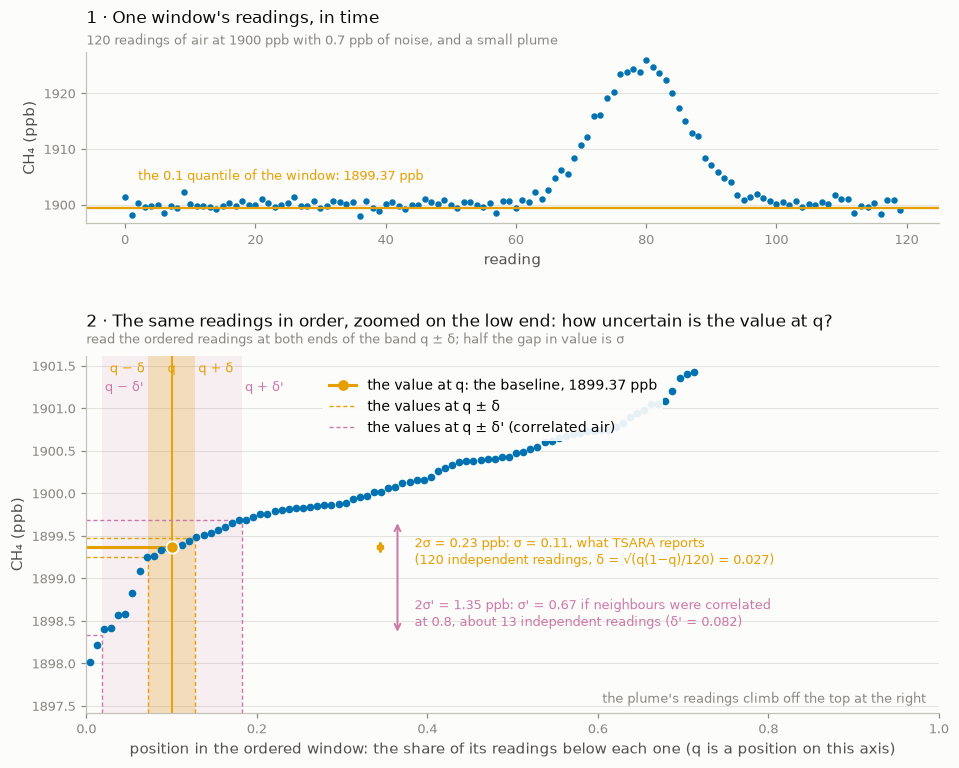

In [16]:
start_section("§7")

# --- one window's Woodruff interval, drawn ------------------------------------
# A window of air with noise and a small plume. Its q-quantile is one position
# on the ordered readings; a quantile of N independent readings is uncertain in
# position by delta = sqrt(q (1 - q) / N), so reading the ordered values at
# q - delta and q + delta gives a spread of values whose half is sigma. With
# correlated neighbours the window holds fewer independent readings (about
# N (1 - rho) / (1 + rho) for AR(1) air), delta is wider, and so is sigma.
drawn_rng = np.random.default_rng(3)
reading = np.arange(DRAWN_N)
drawn = (
    1900
    + 25 * np.exp(-0.5 * ((reading - 0.66 * DRAWN_N) / 7) ** 2)
    + drawn_rng.normal(0, 0.7, DRAWN_N)
)
ones = np.ones(DRAWN_N)


def woodruff_band(n_eff):
    """Return delta, the two positions and the two values Woodruff reads, for n_eff readings."""
    delta = np.sqrt(DRAWN_Q * (1 - DRAWN_Q) / n_eff)
    low, high = max(DRAWN_Q - delta, 0.0), min(DRAWN_Q + delta, 1.0)
    v_low, v_high = (float(weighted_quantile(drawn, ones, [p])[0]) for p in (low, high))
    return delta, low, high, v_low, v_high


at_q = float(weighted_quantile(drawn, ones, [DRAWN_Q])[0])
delta, q_low, q_high, v_low, v_high = woodruff_band(DRAWN_N)
n_correlated = DRAWN_N * (1 - DRAWN_RHO) / (1 + DRAWN_RHO)
delta_c, qc_low, qc_high, vc_low, vc_high = woodruff_band(n_correlated)
sigma_drawn, sigma_correlated = (v_high - v_low) / 2, (vc_high - vc_low) / 2
one_window = uniform_cells("2026-01-01", float(DRAWN_N), 1)  # a window holding every reading
reported = rolling_quantile(uniform_cells("2026-01-01", 1.0, DRAWN_N), drawn, one_window, [DRAWN_Q])
check(
    "§7 the sigma drawn is the one TSARA reports for that window",
    agree(reported.sigma[0, 0], sigma_drawn),
    f"{sigma_drawn:.3f} ppb",
)

# Figure only from here.
fig, (ax, axs) = plt.subplots(
    2, 1, figsize=(10, 7.8), gridspec_kw={"height_ratios": [1.2, 2.5], "hspace": 0.5}
)
ax.plot(reading, drawn, "o", color=C1, ms=3.2)
ax.axhline(at_q, color=C2, lw=1.5)
ax.text(
    2,
    at_q + 4.5,
    f"the {DRAWN_Q:g} quantile of the window: {at_q:.2f} ppb",
    va="bottom",
    color=C2,
    fontsize=8.8,
)
finish(
    ax,
    "1 · One window's readings, in time",
    f"{DRAWN_N} readings of air at 1900 ppb with 0.7 ppb of noise, and a small plume",
    "CH₄ (ppb)",
    "reading",
)
order = np.sort(drawn)
positions = (np.arange(1, DRAWN_N + 1) - 0.5) / DRAWN_N
bottom, top = min(order[0], vc_low) - 0.6, order[0] + 3.6
axs.axvspan(qc_low, qc_high, color=C4, alpha=0.10, lw=0)
axs.axvspan(q_low, q_high, color=C2, alpha=0.22, lw=0)
axs.plot(positions, order, "o", color=C1, ms=4, zorder=3)
axs.axvline(DRAWN_Q, color=C2, lw=1.2)
for p_low, p_high, low, high, colour in (
    (q_low, q_high, v_low, v_high, C2),
    (qc_low, qc_high, vc_low, vc_high, C4),
):
    for p, v in ((p_low, low), (p_high, high)):
        axs.plot([p, p], [bottom, v], color=colour, lw=0.9, ls=(0, (3, 2)))
        axs.plot([0, p], [v, v], color=colour, lw=0.9, ls=(0, (3, 2)))
axs.plot([0, DRAWN_Q], [at_q, at_q], color=C2, lw=2.0)
axs.plot(DRAWN_Q, at_q, "o", color=C2, ms=8, mec=SURFACE, mew=1.2, zorder=5)
# The positions, marked where they sit on the horizontal axis.
for p, text, colour, ha, row in (
    (DRAWN_Q, "q", C2, "center", 0),
    (q_low, "q − δ", C2, "right", 0),
    (q_high, "q + δ", C2, "left", 0),
    (qc_low, "q − δ'", C4, "left", 1),
    (qc_high, "q + δ'", C4, "left", 1),
):
    nudge = 0.004 if ha == "left" else -0.004 if ha == "right" else 0.0
    axs.text(p + nudge, top - 0.08 - 0.22 * row, text, ha=ha, va="top", fontsize=8.6, color=colour)
# The two sigmas, as brackets on the value axis, side by side.
axs.annotate(
    "",
    xy=(0.345, v_low),
    xytext=(0.345, v_high),
    arrowprops={"arrowstyle": "<->", "color": C2, "lw": 1.3},
)
axs.annotate(
    "",
    xy=(0.365, vc_low),
    xytext=(0.365, vc_high),
    arrowprops={"arrowstyle": "<->", "color": C4, "lw": 1.3},
)
axs.text(
    0.385,
    (v_low + v_high) / 2 - 0.05,
    f"2σ = {2 * sigma_drawn:.2f} ppb: σ = {sigma_drawn:.2f}, what TSARA reports\n"
    f"({DRAWN_N} independent readings, δ = √(q(1−q)/{DRAWN_N}) = {delta:.3f})",
    va="center",
    fontsize=8.6,
    color=C2,
)
axs.text(
    0.385,
    vc_low + 0.25,
    f"2σ' = {2 * sigma_correlated:.2f} ppb: σ' = {sigma_correlated:.2f} if neighbours were "
    f"correlated\nat {DRAWN_RHO:g}, about {n_correlated:.0f} independent readings "
    f"(δ' = {delta_c:.3f})",
    va="center",
    fontsize=8.6,
    color=C4,
)
axs.text(
    0.985,
    bottom + 0.08,
    "the plume's readings climb off the top at the right",
    ha="right",
    va="bottom",
    fontsize=8.5,
    color=MUTED,
)
axs.legend(
    handles=[
        Line2D(
            [],
            [],
            color=C2,
            lw=2.0,
            marker="o",
            ms=6,
            label=f"the value at q: the baseline, {at_q:.2f} ppb",
        ),
        Line2D([], [], color=C2, lw=0.9, ls=(0, (3, 2)), label="the values at q ± δ"),
        Line2D(
            [], [], color=C4, lw=0.9, ls=(0, (3, 2)), label="the values at q ± δ' (correlated air)"
        ),
    ],
    loc="upper left",
    bbox_to_anchor=(0.27, 0.97),
    frameon=True,
    facecolor=SURFACE,
    edgecolor="none",
    framealpha=0.92,
)
axs.set_xlim(0, 1)
axs.set_ylim(bottom, top)
finish(
    axs,
    "2 · The same readings in order, zoomed on the low end: how uncertain is the value at q?",
    "read the ordered readings at both ends of the band q ± δ; half the gap in value is σ",
    "CH₄ (ppb)",
    "position in the ordered window: the share of its readings below each one "
    "(q is a position on this axis)",
)
plt.show()

In [17]:
rng = np.random.default_rng(7)

# --- Woodruff against the scatter of the estimator ---------------------------
# Independent standard-normal windows: the sigma the state reports for each
# window's quantile, against how much that quantile actually scatters from
# window to window, and how often the reported interval holds the truth.
cells = uniform_cells("2026-01-01", 1.0, N_PER_WINDOW * N_WINDOWS)
draws = rng.standard_normal(N_PER_WINDOW * N_WINDOWS)
windows = uniform_cells("2026-01-01", float(N_PER_WINDOW), N_WINDOWS)
rolled = rolling_quantile(cells, draws, windows, [Q])
truth = float(np.quantile(rng.standard_normal(2_000_000), Q))
estimates, sigmas = rolled.values[:, 0], rolled.sigma[:, 0]
ratio = float(np.mean(sigmas) / np.std(estimates))
covered = float(np.mean(np.abs(estimates - truth) <= sigmas))
print(
    f"independent draws, N = {N_PER_WINDOW}, q = {Q}: reported sigma / observed scatter "
    f"= {ratio:.3f}; the interval holds the true quantile in {covered:.0%} of windows"
)
check(
    "§7 Woodruff's sigma equals the reference written from its definition, window by window",
    np.allclose(
        sigmas[:50],
        [
            reference_woodruff(
                draws[k * N_PER_WINDOW : (k + 1) * N_PER_WINDOW], np.ones(N_PER_WINDOW), Q
            )
            for k in range(50)
        ],
        rtol=1e-9,
    ),
    "the first fifty windows",
)
check(
    "§7 on independent draws the reported sigma is the scatter of the estimate to within a factor",
    0.8 < ratio < 1.3 and 0.58 < covered < 0.78,
    f"ratio {ratio:.2f}, coverage {covered:.0%}; METHODS §6.7 measured 1.03 and 0.66 "
    "at N = 200, q = 0.05",
)

# The floor: on strongly autocorrelated "air" the readings in a window are not
# exchangeable, the quantile scatters far more from window to window than the
# within-window spread suggests, and the reported figure is a fraction of it.
noise = rng.standard_normal(N_PER_WINDOW * N_WINDOWS)
air = np.empty_like(noise)
air[0] = noise[0]
scale = np.sqrt(1 - RHO**2)
for i in range(1, air.size):
    air[i] = RHO * air[i - 1] + scale * noise[i]
rolled_air = rolling_quantile(cells, air, windows, [Q])
ratio_air = float(np.mean(rolled_air.sigma[:, 0]) / np.std(rolled_air.values[:, 0]))
print(f"AR(1) air, lag-one correlation {RHO}: reported sigma / observed scatter = {ratio_air:.3f}")
if RHO >= 0.5:
    # Correlated readings carry less independent information than their number,
    # so the quantile scatters more than the exchangeable figure says: the ratio
    # falls below the independent case by more than the Monte Carlo's own error.
    check(
        "§7 on autocorrelated air the reported sigma is a floor: below the scatter it reports "
        "on independent draws",
        ratio_air < ratio * (1 - sampling_tolerance(N_WINDOWS)),
        f"ratio {ratio_air:.2f} against {ratio:.2f} on independent draws; "
        "the attribute says 'floor'",
    )
else:
    print("  (RHO under 0.5: the air is close to independent and the floor close to the scatter)")

# --- the enhancement's systematic sigma: a gain scales it, an offset cancels --
# A noise-free record, then the SAME error applied to every reading, so that
# the baseline inherits it exactly as a real calibration error would.
data = landfill_campaign(duration="3h", noise_ppb=None, blips_per_hour=6.0)
clean = measured(data.streams["analyzer"])
settings = sweep(windows=("2min", "60min"), quantiles=(Q,))
true_state = baseline_state(clean, instrument="analyzer", baseline=settings)
delta_true = true_state["enhancement_ch4"].values


def with_error(gain, offset, declared):
    """Return the clean stream as (1 + gain) * true + offset, its systematic sigma declared."""
    wrong = clean.copy(deep=True)
    wrong["ch4"] = wrong["ch4"] * (1 + gain) + offset
    wrong["sigma_sys_ch4"] = (
        "time",
        declared,
        {
            "units": "ppb",
            "uncertainty_component": "systematic",
            "uncertainty_provenance": "declared",
        },
    )
    return wrong


x = clean["ch4"].values
for label, gain, offset in (
    ("a pure gain error", GAIN, 0.0),
    ("a pure offset error", 0.0, OFFSET_PPB),
):
    declared = np.abs(gain) * x + abs(offset)  # what a manifest would declare per point
    state = baseline_state(
        with_error(gain, offset, declared), instrument="analyzer", baseline=settings
    )
    delta = state["enhancement_ch4"].values
    figure = state["sigma_sys_enhancement_ch4"].values
    actual = np.abs(delta - delta_true)
    finite = np.isfinite(actual) & np.isfinite(figure) & (np.abs(delta_true) > 5.0)
    rule = state["sigma_sys_enhancement_ch4"].attrs["tsara_sigma_rule"]
    print(f"\n{label}: rule '{rule}'")
    print(
        f"  median actual |Δ error| {np.median(actual[finite]):.3f} ppb, "
        f"median reported sigma {np.median(figure[finite]):.3f} ppb"
    )
    if gain:
        check(
            f"§7 under {label} the reported systematic sigma of Δ is the actual error, exactly",
            np.allclose(actual[finite], figure[finite], rtol=1e-6, atol=1e-9),
        )
    else:
        check(
            f"§7 under {label} the error of Δ is nil and the reported sigma bounds it above",
            np.nanmax(actual[finite]) < 1e-6 and bool((figure[finite] >= actual[finite]).all()),
            f"reported {np.median(figure[finite]):.3f} ppb where the true error is 0: "
            "the bound, not the value",
        )

# --- the enhancement's random sigma: the reading's and the baseline's in quadrature
noisy = landfill_campaign(duration="3h", noise_ppb=0.7, blips_per_hour=6.0)
stream = measured(noisy.streams["analyzer"])
stream["sigma_rand_ch4"] = (
    "time",
    noisy.streams["analyzer"]["truth_sigma_rand_ch4"].values,
    {"units": "ppb", "uncertainty_component": "random", "uncertainty_provenance": "declared"},
)
state = baseline_state(stream, instrument="analyzer", baseline=settings)
want = np.sqrt(
    stream["sigma_rand_ch4"].values[:, None, None] ** 2
    + state["sigma_rand_baseline_ch4"].values ** 2
)
got = state["sigma_rand_enhancement_ch4"].values
finite = np.isfinite(got)
check(
    "§7 the enhancement's random sigma is the reading's and the baseline's in quadrature",
    np.allclose(got[finite], want[finite]),
)
print(
    f"\nwith 0.7 ppb of noise, the enhancement's random sigma is {np.nanmedian(got):.3f} ppb: "
    f"the reading's noise, plus a baseline sigma of "
    f"{np.nanmedian(state['sigma_rand_baseline_ch4'].values):.3f} ppb in quadrature"
)

# A reading that declares no random sigma: the enhancement gets no random sigma
# column, and says so, rather than borrowing an estimate (METHODS §6.7).
bare = baseline_state(measured(noisy.streams["analyzer"]), instrument="analyzer", baseline=settings)
said = bare["enhancement_ch4"].attrs.get("uncertainty_provenance_random")
print(f"without a declared sigma, the enhancement's random uncertainty is recorded as '{said}'")
check(
    "§7 an enhancement whose reading declares no sigma says 'unknown' instead of inventing one",
    "sigma_rand_enhancement_ch4" not in bare.data_vars and said == "unknown",
)

independent draws, N = 200, q = 0.05: reported sigma / observed scatter = 1.043; the interval holds the true quantile in 66% of windows
  ✔ §7 Woodruff's sigma equals the reference written from its definition, window by window   [the first fifty windows]
  ✔ §7 on independent draws the reported sigma is the scatter of the estimate to within a factor   [ratio 1.04, coverage 66%; METHODS §6.7 measured 1.03 and 0.66 at N = 200, q = 0.05]


AR(1) air, lag-one correlation 0.99: reported sigma / observed scatter = 0.077
  ✔ §7 on autocorrelated air the reported sigma is a floor: below the scatter it reports on independent draws   [ratio 0.08 against 1.04 on independent draws; the attribute says 'floor']



a pure gain error: rule 'same instrument: sigma_sys(x) |enhancement| / |x|'
  median actual |Δ error| 0.692 ppb, median reported sigma 0.692 ppb
  ✔ §7 under a pure gain error the reported systematic sigma of Δ is the actual error, exactly



a pure offset error: rule 'same instrument: sigma_sys(x) |enhancement| / |x|'
  median actual |Δ error| 0.000 ppb, median reported sigma 0.266 ppb
  ✔ §7 under a pure offset error the error of Δ is nil and the reported sigma bounds it above   [reported 0.266 ppb where the true error is 0: the bound, not the value]


  ✔ §7 the enhancement's random sigma is the reading's and the baseline's in quadrature

with 0.7 ppb of noise, the enhancement's random sigma is 0.701 ppb: the reading's noise, plus a baseline sigma of 0.034 ppb in quadrature


without a declared sigma, the enhancement's random uncertainty is recorded as 'unknown'
  ✔ §7 an enhancement whose reading declares no sigma says 'unknown' instead of inventing one


**What to read off the output.** The figure is one window: its readings in
order, the band of positions a quantile of that many readings could fall in,
and the values at the band's ends; half their gap is σ. With neighbours
correlated at 0.8 the same readings are worth about a ninth as many
independent ones, the band is three times wider, and σ several times larger:
the reported figure is what the uncertainty is at least. On independent draws Woodruff's sigma is the
scatter of the estimate to within a few percent, and its interval holds the
truth about two thirds of the time, which is what a one-sigma figure means.
On air correlated at 0.99 per reading the same figure is a small fraction of
the true scatter: a window of such air holds far fewer independent draws than
readings. That is why the state labels the figure a floor in
`tsara_sigma_assumption` rather than calling it the baseline's uncertainty; the
spread that matters, across windows and quantiles, is the sweep's, and Phase 7
reads it.

The gain-and-offset pair is §6.7's argument run rather than reasoned. Under a
2 % gain error every reading and every baseline is 2 % high, the enhancement is
2 % high, and the state's σ_sys(*x*)·|Δ|/|*x*| is that error exactly. Under a
15 ppb offset the enhancement is untouched, because the offset cancels in the
difference, and the state's figure is an upper bound of a few tenths of a ppb.
The stream cannot say which kind of error it carries, so the bound is what is
written; a 1 % gain error on 1900 ppb is 19 ppb on the reading and under a ppb
on a typical enhancement, which is the number a regression should see.

Where the reading declares no random sigma at all, as none of the generator's
streams do unless asked, the enhancement gets no random sigma column and says
`unknown` in its `uncertainty_provenance_random`. Nothing estimated stands in:
the noise scale that could is detection's (Phase 6), and on a real drive it
measures the air as much as the instrument (`METHODS.md` §2.5).

**Try it.** `RHO = 0.5`: mildly correlated air, and the floor is only mildly
low (a ratio near 0.8 rather than 0.08). `N_PER_WINDOW = 50`: fewer readings, and Woodruff runs a little high (the
interval is asymmetric in the tail; METHODS §6.7 tabulates it). `GAIN = 0.10`:
still exact, since the argument is algebraic.

---
## 8. The state saves, reloads exactly, and joins like a stream

**The question.** Rolling takes time (`METHODS.md` §6.3 measured about half a
minute per species for a 60 min window over 200 000 readings), so the state
must survive a save and a reload without losing a bit, and what comes back
must be usable by every later stage: joined onto other cells the way a stream
is.

`save_state` writes one netCDF file per instrument into a bundle beside the
streams, with the baseline configuration that produced them; `load_state`
brings them back (`src/tsara/baseline/bundle.py`). A reloaded state keeps each
reading's cell, so the binner of Phase 4 puts its baseline and enhancement on
any cells a question names, every version of the sweep at once (§11.2 of
`METHODS.md`, *swept variables*). Below, the state is put on 60 s cells: one
row per minute, one column per sweep point, the receptor-row shape.

In [18]:
# ---- PARAMETERS (section 8) --------------------------------------------------
CELL_S = 60.0  # the cells the reloaded state is joined onto
COMPRESSION = 4  # zlib level for the second save, or None

In [19]:
start_section("§8")
data = landfill_campaign(duration="2h")
stream = measured(data.streams["analyzer"])
settings = sweep()
states = {"analyzer": baseline_state(stream, instrument="analyzer", baseline=settings)}
plain = save_state(states, WORK / "plain", baseline=settings)
small = save_state(states, WORK / "small", baseline=settings, compression=COMPRESSION)
back = load_state(WORK / "plain")
again = back.states["analyzer"]
size_plain, size_small = (
    (plain / "analyzer.nc").stat().st_size,
    (small / "analyzer.nc").stat().st_size,
)
print(
    f"written: {sorted(p.name for p in plain.iterdir())}; {size_plain / 1e6:.1f} MB plain, "
    f"{size_small / 1e6:.1f} MB at zlib level {COMPRESSION}"
)


def identical(a, b):
    """Every variable and coordinate exactly, every attribute exactly, arrays included."""
    if sorted(map(str, a.variables)) != sorted(map(str, b.variables)):
        return False
    for name in a.variables:
        if not same(a[name].values, b[name].values):
            return False
        for key, value in a[name].attrs.items():
            if name == "time" and key == "bounds":
                continue  # moved into encoding on load, by xarray's CF decoding
            other = b[name].attrs.get(key)
            if isinstance(value, np.ndarray):
                if not np.array_equal(value, other):
                    return False
            elif value != other:
                return False
    return a.attrs == b.attrs


check(
    "§8 the reloaded state is the saved one, every variable and attribute exactly",
    identical(states["analyzer"], again),
)
if COMPRESSION:
    check(
        "§8 the compressed file reloads to the same state and is smaller",
        identical(again, load_state(WORK / "small").states["analyzer"]) and size_small < size_plain,
    )
else:
    check(
        "§8 the second save, uncompressed, reloads to the same state",
        identical(again, load_state(WORK / "small").states["analyzer"]),
    )
check("§8 the baseline configuration comes back beside the states", back.baseline == settings)

# Joined like a stream: the reloaded state's swept variables onto minute cells.
cells = uniform_cells(again["time"].values[0], CELL_S, int(np.ceil(again.sizes["time"] / CELL_S)))
joined = bin_streams_onto_cells(
    {"analyzer": again},
    cells,
    [("analyzer", "enhancement_ch4"), ("analyzer", "baseline_ch4"), ("analyzer", "ch4")],
)
print(f"\njoined onto {CELL_S:g} s cells: {dict(joined.sizes)}")
print(f"columns: {sorted(map(str, joined.data_vars))[:8]} ...")
one_by_one = np.empty_like(joined["enhancement_ch4"].values)
for w in range(joined.sizes["baseline_window"]):
    for q in range(joined.sizes["baseline_quantile"]):
        version = (
            again[["enhancement_ch4"]]
            .isel(baseline_window=w, baseline_quantile=q)
            .drop_vars(["baseline_window", "baseline_quantile"])
        )
        version.coords["time_bnds"] = again["time_bnds"]
        one_by_one[:, w, q] = bin_streams_onto_cells({"analyzer": version}, cells)[
            "enhancement_ch4"
        ].values
check(
    "§8 every version of the swept enhancement is joined as it would be joined alone",
    same(joined["enhancement_ch4"].values, one_by_one),
)
# The join of a difference is the difference of the joins only where the same
# readings contributed to all three columns: a cell holding a blank baseline
# averages fewer readings into the baseline than into the reading.
same_readings = (
    joined["n_readings_enhancement_ch4"].values == joined["n_readings_ch4"].values[:, None, None]
) & (joined["n_readings_enhancement_ch4"].values == joined["n_readings_baseline_ch4"].values)
difference = joined["ch4"].values[:, None, None] - joined["baseline_ch4"].values
check(
    "§8 where the same readings formed all three columns, the joined enhancement is the joined "
    "reading minus the joined baseline",
    np.allclose(joined["enhancement_ch4"].values[same_readings], difference[same_readings])
    and same_readings.mean() > 0.5,
    "every cell"
    if same_readings.all()
    else f"{same_readings.mean():.0%} of cells; the others hold a blank baseline for some reading",
)
table = pd.DataFrame(
    {
        "minute": pd.to_datetime(joined["time"].values[:6]).strftime("%H:%M"),
        "ch4": joined["ch4"].values[:6].round(1),
        **{
            f"Δ @{w}/{q:g}": joined["enhancement_ch4"]
            .sel(baseline_window=pd.Timedelta(w).total_seconds(), baseline_quantile=q)
            .values[:6]
            .round(1)
            for w in settings.windows[::2]
            for q in settings.quantiles[1:2]
        },
    }
)
print("\nthe first six rows, a few of the sweep's columns:")
print(table.to_string(index=False))

written: ['analysis.yaml', 'analyzer.nc']; 2.2 MB plain, 0.8 MB at zlib level 4
  ✔ §8 the reloaded state is the saved one, every variable and attribute exactly
  ✔ §8 the compressed file reloads to the same state and is smaller
  ✔ §8 the baseline configuration comes back beside the states

joined onto 60 s cells: {'time': 120, 'baseline_window': 3, 'baseline_quantile': 3, 'nv': 2}
columns: ['baseline_ch4', 'borrowed_baseline_ch4', 'borrowed_ch4', 'borrowed_enhancement_ch4', 'ch4', 'coverage_baseline_ch4', 'coverage_ch4', 'coverage_enhancement_ch4'] ...
  ✔ §8 every version of the swept enhancement is joined as it would be joined alone
  ✔ §8 where the same readings formed all three columns, the joined enhancement is the joined reading minus the joined baseline   [100% of cells; the others hold a blank baseline for some reading]

the first six rows, a few of the sweep's columns:
minute    ch4  Δ @2min/0.05  Δ @60min/0.05
 10:00 1900.1           1.2            1.1
 10:01 1900.1        

**What to read off the output.** The round trip loses nothing: values,
coordinates, the cell boundaries, and the per-sweep-point records that are
arrays in the attributes all come back equal. Compression is a choice at save
time and changes only the size. And the reloaded state joins as a stream does:
one call puts every version of the enhancement on minute cells, and each
version equals what joining it alone would give, so a receptor-model matrix is
still "the binner called with a chosen set of columns", now with a sweep
inside.

**Try it.** `CELL_S = 600`: ten-minute rows. The 2 min window's enhancement
does not average away in them (several ppb in the first rows, close to the
60 min window's): averaging onto a longer cell keeps every blip's contribution
and spreads it over the row, which is why `METHODS.md` §11.7.1 rejected a
median for joining. `COMPRESSION = None`: the second file is as large as the
first, and it still reloads to the same state.

---
## 9. Scoreboard, and what is known to be imperfect

Every check in this notebook, as it ran. Then the limits this phase records
rather than resolves.

In [20]:
held = sum(1 for ok, _ in CHECKS.values() if ok)
print(f"{held} of {len(CHECKS)} checks hold\n")
for claim, (ok, detail) in CHECKS.items():
    print(f"  {'✔' if ok else '✘'} {claim}" + (f"   [{detail}]" if detail else ""))

56 of 56 checks hold

  ✔ §1 TSARA's weighted quantile equals the one written from the definition
  ✔ §1 rolling is this, at every reading: the engine's value at the examined reading is it
  ✔ §1 with equal weights it is numpy's Hazen rule, at every q
  ✔ §1 the order of the readings does not matter
  ✔ §1 a reading with no weight, or no value, takes no part
  ✔ §2 the baseline at 2min is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 2min
  ✔ §2 the baseline at 20min is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 20min
  ✔ §2 the baseline at 2h is the definition, window by window
  ✔ §2 its window count and coverage are the definition's, at 2h
  ✔ §2 the enhancement is the reading minus the baseline, blank where either is
  ✔ §2 enhancements are never clipped: noise below the baseline stays negative
  ✔ §2 the baseline carries no cell_methods; the enhancement inherits the reading's
  ✔ §

### Known to be imperfect, and where each is written down

* **Two numbers assume independent readings.** Woodruff's sigma is a floor on
  the baseline's sampling error: on autocorrelated air it understates the
  scatter by a large factor (§7; `METHODS.md` §6.7 measured 0.08 at a lag-one
  correlation of 0.99), and the attribute says so. The count rule is a floor in
  the same way: correlated air behaves like fewer readings than it has (§3;
  §6.4). The spread across the sweep is Phase 7's to read.
* **A window is a duration.** On a moving platform it is a stretch of road as
  much as an interval of air, so the baseline inherits the cell model's open
  limitation (CLAUDE.md, open flags; `METHODS.md` §6.3) rather than resolving it.
* **`from_field` is three calls, and hands over the donor's noise offset.** The
  stages of TSARA hand each other Datasets and never import each other (§5), so
  the Phase-9 pipeline will make it one line. The adopted baseline sits the
  donor's *z_q*·σ below the background, so the adopter's enhancement is lifted
  by the donor's noise, about 0.05 ppb on every canister fill of the 2024-07-18
  drive; detection has to correct it with the donor's σ (§6.5, §6.8).
* **The rolling engine is eager and block-bounded.** A six-hour window on a
  10 Hz record fits in memory and would take hours; `METHODS.md` §6.3 gives the
  arithmetic and names the sorted-sweep form as the upgrade path if such a
  record arrives.
* **A parent plume fitted over its interval measures its children.** Measured
  with the answer key (§6.1): a landfill's ethane ratio comes out as the gas
  line's inside it, at every window. Two readings of this state recover it;
  which one Phase 6 and 7 use is open.
* **A non-zero constant has no uncertainty of its own**, and a constant's
  spread across the sweep is zero because it has no windows (§6; §6.5).